# Análisis exploratorio de variables
### Autor: Diego Sánchez de la Fuente

In [1]:
# Imports necesarios core
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
# Para graficar
from matplotlib import pyplot as plt
import plotly.express as px
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [3]:
# Estadistica
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp
from scipy.stats import spearmanr
from scipy.stats import kruskal

In [4]:
# Modelados
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

In [5]:
# Refgularizacion de modelos
import sys
from pathlib import Path

# sube desde Prueba/ a project_root/
ROOT = Path.cwd().resolve()

# si el notebook se abre desde Prueba/, subimos un nivel
if (ROOT / "src").exists() is False:
    ROOT = ROOT.parent

# añade project_root al PYTHONPATH de la sesión
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.model_lagrangian import lagrangian_rank

In [6]:
df_tablon = pd.read_parquet("../data/processed/final/tablon_final_v3.parquet")

# Análisis de las variables del tablón

In [7]:
df_tablon.columns

Index(['pub', 'ops_pub_date', 'roi_proxy', 'roi_class', 'ops_n_applicants',
       'ops_n_inventors', 'ops_n_ipc', 'ops_n_cpc', 'ops_ipc_main',
       'family_size_simple', 'family_country_count_simple',
       'family_kinds_count_simple', 'legal_events_count', 'legal_codes_unique',
       'legal_first_date', 'legal_last_date', 'legal_has_grant_like',
       'legal_has_opposition_like', 'ops_pub_date_biblio',
       'ops_n_applicants_biblio', 'ops_n_inventors_biblio', 'ops_n_cpc_biblio',
       'ops_n_ipc_biblio', 'ops_ipc_main_biblio', 'ops_title', 'ops_abstract',
       'biblio_priority_count', 'biblio_priority_date_min',
       'biblio_priority_year', 'biblio_application_date',
       'biblio_application_year', 'biblio_publication_date',
       'biblio_publication_year', 'biblio_kind', 'biblio_title',
       'biblio_abstract', 'party_applicant_count', 'party_inventor_count',
       'party_applicant_country_list', 'party_applicant_country_count',
       'party_applicant_country_main'

In [8]:
# Features a excluir:
EXCLUDE_FEATURES = [
    # Targets
    "roi_proxy",
    "roi_proxy_v2",
    "roi_proxy_v3",
    "cost_proxy_v2",
    "roi_class",

    # Componentes directos del proxy ROI
    "family_size_simple",
    "log_family_size",
    "legal_events_count",
    "legal_codes_unique",
    "tech_breadth_proxy",
]

## Definición de las variables de tablón:

### Identificación y fechas básicas

| Variable                  | Descripción                                                                               |
| ------------------------- | ----------------------------------------------------------------------------------------- |
| **`pub`**                 | Identificador único de la publicación de patente (clave primaria del tablón).             |
| **`ops_pub_date`**        | Fecha oficial de publicación según OPS.                                                   |
| **`ops_pub_date_biblio`** | Fecha de publicación obtenida del bloque bibliográfico (fuente alternativa de contraste). |
| **`pub_prefix`**          | Prefijo del número de publicación (EP, US, WO, CN, etc.), indica jurisdicción.            |
| **`pub_year`**            | Año de publicación (extraído de la fecha).                                                |
| **`pub_month`**           | Mes de publicación (extraído de la fecha).                                                |
| **`patent_age_days`**     | Antigüedad de la patente en días desde su publicación.                                    |
| **`patent_age_years`**    | Antigüedad de la patente en años (proxy temporal más interpretable).                      |

(*) Variables temporales clave para analizar madurez, ciclo de vida y efectos de supervivencia.

### Variables objetivo (ROI y proxies económicos)

| Variable            | Descripción                                                                                            |
| ------------------- | ------------------------------------------------------------------------------------------------------ |
| **`roi_proxy`**     | Proxy inicial del retorno económico estimado de la patente, construido a partir de señales indirectas. |
| **`roi_class`**     | Discretización del `roi_proxy` en clases (por ejemplo: bajo / medio / alto).                           |
| **`roi_proxy_v2`**  | Segunda versión del proxy ROI, refinada (p. ej. ponderaciones distintas).                              |
| **`roi_proxy_v3`**  | Tercera versión del proxy ROI, más robusta o conservadora.                                             |
| **`roi_class`**  | Clasificación derivada del `roi_proxy_v3`.                                                             |
| **`cost_proxy_v2`** | Proxy del coste económico asociado a la patente (tramitación, mantenimiento, complejidad).             |

(*) Estas variables no representan ROI real, sino aproximaciones observables útiles para análisis comparativos y modelos explicativos.


### Actores de la patente (complejidad organizativa)

| Variable                      | Descripción                                        |
| ----------------------------- | -------------------------------------------------- |
| **`ops_n_applicants`**        | Número de solicitantes de la patente (fuente OPS). |
| **`ops_n_inventors`**         | Número de inventores asociados.                    |
| **`ops_n_applicants_biblio`** | Número de solicitantes según datos bibliográficos. |
| **`ops_n_inventors_biblio`**  | Número de inventores según datos bibliográficos.   |

(*) Mayor número de actores suele asociarse a:
- proyectos más complejos
- consorcios
- mayor inversión inicial

### Clasificación tecnológica (IPC / CPC)

| Variable                  | Descripción                                                   |
| ------------------------- | ------------------------------------------------------------- |
| **`ops_n_ipc`**           | Número de códigos IPC asignados.                              |
| **`ops_n_cpc`**           | Número de códigos CPC asignados.                              |
| **`ops_ipc_main`**        | Código IPC principal de la patente.                           |
| **`ops_n_ipc_biblio`**    | Número de IPC según bibliografía.                             |
| **`ops_n_cpc_biblio`**    | Número de CPC según bibliografía.                             |
| **`ops_ipc_main_biblio`** | IPC principal según bibliografía.                             |
| **`tech_breadth_proxy`**  | Proxy de amplitud tecnológica (diversidad de clases IPC/CPC). |

(*) Más códigos → mayor complejidad o transversalidad tecnológica. El valor **`tech_breadth`** se suele relacionar con mayor potencial de explotación.


### Familia de patentes (estrategia internacional)

| Variable                          | Descripción                                               |
| --------------------------------- | --------------------------------------------------------- |
| **`family_size_simple`**          | Número total de miembros de la familia de patentes.       |
| **`family_country_count_simple`** | Número de países cubiertos por la familia.                |
| **`family_kinds_count_simple`**   | Número de tipos de documentos (A, B, etc.) en la familia. |
| **`log_family_size`**             | Logaritmo del tamaño de la familia (reduce asimetría).    |

(*) Familias grandes y multinacionales suelen implicar:
- mayor inversión
- mayor expectativa de retorno
- estrategia comercial más ambiciosa

Calculo de la variable: **`log_family_size`**

<code>
    log_family_size = log(1 + family_size_simple)
</code>
<br>
(*) La variable log_family_size es una transformación logarítmica del tamaño de la familia de patentes, calculada para reducir la asimetría de la distribución y evitar que familias excepcionalmente grandes dominen el análisis. Esta transformación es habitual en estudios bibliométricos y econométricos relacionados con propiedad industrial.


### Eventos legales y estado jurídico

| Variable                        | Descripción                                      |
| ------------------------------- | ------------------------------------------------ |
| **`legal_events_count`**        | Número total de eventos legales registrados.     |
| **`legal_codes_unique`**        | Número de códigos legales distintos.             |
| **`legal_first_date`**          | Fecha del primer evento legal.                   |
| **`legal_last_date`**           | Fecha del último evento legal.                   |
| **`legal_has_grant_like`**      | Indicador binario de concesión o evento similar. |
| **`legal_has_opposition_like`** | Indicador binario de oposición o conflicto.      |
| **`legal_missing_dates`**       | Número de eventos legales sin fecha válida.      |

(*) Más eventos → patente “viva” o disputada. Oposiciones → posible alto valor o interés competitivo.


### Métricas temporales derivadas del historial legal

| Variable                      | Descripción                                  |
| ----------------------------- | -------------------------------------------- |
| **`years_since_first_legal`** | Años desde el primer evento legal.           |
| **`years_since_last_legal`**  | Años desde el último evento legal.           |
| **`alive_span_days`**         | Duración total de vida legal en días.        |
| **`alive_years`**             | Duración total de vida legal en años.        |
| **`events_per_year`**         | Frecuencia media de eventos legales por año. |
| **`is_active_recent`**        | Indicador de actividad legal reciente.       |

(*) Estas variables capturan dinámica y persistencia de la patente en el tiempo.

(*) **`years_since_first_legal`** y **`years_since_last_legal`** se calculan en el momento de generar el tabón.

### Texto y longitud (señales semánticas simples)

| Variable           | Descripción                                          |
| ------------------ | ---------------------------------------------------- |
| **`ops_title`**    | Título de la patente.                                |
| **`ops_abstract`** | Resumen (abstract) de la patente.                    |
| **`title_len`**    | Longitud del título (número de caracteres o tokens). |
| **`abstract_len`** | Longitud del abstract.                               |

(*) Abstracts más largos pueden reflejar mayor complejidad técnica, Variables útiles como proxies simples antes de NLP avanzado. 





## Identificación, bibliografía y fechas clave

| Variable | Descripción |
|--------|-------------|
| **`biblio_priority_count`** | Número de prioridades reivindicadas por la patente. |
| **`biblio_priority_date_min`** | Fecha de prioridad más antigua declarada. |
| **`biblio_priority_year`** | Año correspondiente a la prioridad más antigua. |
| **`biblio_application_date`** | Fecha oficial de solicitud de la patente. |
| **`biblio_application_year`** | Año de solicitud. |
| **`biblio_publication_date`** | Fecha oficial de publicación. |
| **`biblio_publication_year`** | Año de publicación. |
| **`biblio_kind`** | Código *kind* del documento (A1, B1, etc.), indica fase y naturaleza del documento. |

(*) Estas variables permiten reconstruir la **línea temporal administrativa** de la patente y analizar retrasos, madurez y ventanas de explotación.

---

## Título y resumen (fuente bibliográfica)

| Variable | Descripción |
|--------|-------------|
| **`biblio_title`** | Título de la patente según el bloque bibliográfico. |
| **`biblio_abstract`** | Resumen (abstract) según datos bibliográficos. |

(*) Se utilizan como **fuente base de contraste** frente a texto full-text cuando existe.

---

## Actores de la patente (estructura organizativa)

| Variable | Descripción |
|--------|-------------|
| **`party_applicant_count`** | Número total de solicitantes. |
| **`party_inventor_count`** | Número total de inventores. |
| **`party_applicant_country_list`** | Lista de países de los solicitantes. |
| **`party_applicant_country_count`** | Número de países distintos representados. |
| **`party_applicant_country_main`** | País principal del solicitante (heurística dominante). |
| **`party_applicant_type_main`** | Tipo principal de solicitante (empresa, universidad, individuo, etc.). |
| **`party_applicant_type_conf`** | Grado de confianza del tipo dominante de solicitante. |

(*) Un mayor número de actores o países suele correlacionar con:
- mayor inversión inicial  
- proyectos colaborativos o consorciados  
- estrategias de protección más complejas  

---

## Texto completo y disponibilidad semántica

| Variable | Descripción |
|--------|-------------|
| **`text_title`** | Título consolidado para análisis textual. |
| **`text_abstract`** | Abstract consolidado. |
| **`text_claims`** | Texto completo de las reivindicaciones. |
| **`text_description`** | Texto completo de la descripción. |
| **`text_has_claims`** | Indicador binario de disponibilidad de claims. |
| **`text_has_description`** | Indicador binario de disponibilidad de description. |
| **`text_available`** | Indica si existe texto suficiente para análisis semántico. |

(*) Estas variables determinan si la patente es **usable para NLP, embeddings y análisis semántico avanzado**.

---

## Longitud del texto (proxies de complejidad técnica)

| Variable | Descripción |
|--------|-------------|
| **`text_len_title`** | Longitud del título. |
| **`text_len_abstract`** | Longitud del abstract. |
| **`text_len_claims`** | Longitud de las reivindicaciones. |
| **`text_len_description`** | Longitud de la descripción. |

(*) Textos más largos suelen reflejar:
- mayor densidad técnica  
- mayor esfuerzo redaccional  
- invenciones más complejas  

Estas métricas funcionan como **proxies simples previos a NLP**.

---

## Texto preparado para embeddings

| Variable | Descripción |
|--------|-------------|
| **`text_for_embedding`** | Texto unificado y limpio utilizado para generar embeddings. |
| **`text_len_embedding`** | Longitud total del texto de entrada al modelo de embeddings. |

(**) `text_for_embedding` suele construirse concatenando:
- título  
- abstract  
- resumen de claims  
- fragmentos relevantes de description  

Esta variable es clave para modelos semánticos y explicativos.

---

## Jurisdicción y país de publicación

| Variable | Descripción |
|--------|-------------|
| **`pub_prefix`** | Prefijo del número de publicación (EP, US, WO, CN, etc.). |
| **`pub_is_ep`** | Indicador binario de publicación europea. |
| **`pub_is_us`** | Indicador binario de publicación estadounidense. |
| **`pub_is_wo`** | Indicador binario de publicación internacional (PCT). |
| **`pub_is_cn`** | Indicador binario de publicación china. |
| **`pub_is_jp`** | Indicador binario de publicación japonesa. |
| **`pub_is_kr`** | Indicador binario de publicación coreana. |
| **`pub_is_de`** | Indicador binario de publicación alemana. |
| **`pub_is_fr`** | Indicador binario de publicación francesa. |
| **`pub_is_gb`** | Indicador binario de publicación británica. |
| **`pub_is_es`** | Indicador binario de publicación española. |
| **`pub_year`** | Año de publicación. |
| **`pub_month`** | Mes de publicación. |

(*) La jurisdicción es una **señal estratégica** del mercado objetivo.

---

## Antigüedad de la patente (proxy temporal)

| Variable | Descripción |
|--------|-------------|
| **`patent_age_days`** | Antigüedad de la patente en días desde la publicación. |
| **`patent_age_years`** | Antigüedad en años (proxy temporal más interpretable). |

(*) Variables clave para analizar:
- madurez tecnológica  
- obsolescencia  
- efectos de supervivencia  

---

## Proxies de complejidad y alcance tecnológico

| Variable | Descripción |
|--------|-------------|
| **`tech_breadth_proxy`** | Proxy de amplitud tecnológica basado en diversidad IPC/CPC. |

(**) Cálculo típico:
```python
tech_breadth_proxy = len(set(ipc_codes + cpc_codes))


## Distribuciones de las variables

## Variables objetivo: ROI y proxies economicos

El retorno economico real no es directamente observable, por lo que se definen proxies heurísticos a partir de señales indirectas.

---

### 1. Proxy inicial de retorno economico (roi_proxy)

Definicion general:

$$
ROI = \sum_{i=1}^{K} w_i x_i
$$

Forma explicita:

$$
ROI = w_1 F + w_2 C + w_3 L + w_4 T
$$

donde:
- F = tamano de familia
- C = numero de paises
- L = numero de eventos legales
- T = complejidad tecnologica

---

### 2. Clasificacion del ROI (roi_class)

$$
ROI\_class =
\begin{cases}
1 & ROI < \tau_1 \\
2 & \tau_1 \le ROI < \tau_2 \\
3 & ROI \ge \tau_2
\end{cases}
$$

donde x_i representa la i-esima señal observable asociada a una patente
(tamano de familia, numero de paises, eventos legales, complejidad tecnologica, etc.)
y w_i su peso correspondiente.



---

### 3. Proxy ROI refinado (roi_proxy_v2)

$$
ROI^{(2)} = \sum_{i=1}^{K} w_i \log(1 + x_i)
$$

---

### 4. Proxy ROI robusto (roi_proxy_v3)

Forma penalizada:

$$
ROI^{(3)} = ROI^{(2)} - \lambda \cdot COST
$$

Forma normalizada:

$$
ROI^{(3)} = \frac{ROI^{(2)}}{1 + \lambda \cdot COST}
$$

---

### 5. Clasificacion basada en ROI v3 (roi_class_v3)

$$
ROI^{(3)}\_class =
\begin{cases}
1 & ROI^{(3)} < \tau_1^{(3)} \\
2 & \tau_1^{(3)} \le ROI^{(3)} < \tau_2^{(3)} \\
3 & ROI^{(3)} \ge \tau_2^{(3)}
\end{cases}
$$

---

### 6. Proxy de coste economico (cost_proxy_v2)

$$
COST = \alpha_1 F + \alpha_2 C + \alpha_3 L + \alpha_4 T
$$

Forma suavizada:

$$
COST = \sum_{j=1}^{M} \alpha_j \log(1 + c_j)
$$

---

### 7. Interpretacion economica

$$
U = ROI - COST
$$

El proxy <b><i>ROI</i></b> puede interpretarse como una funcion de utilidad aproximada, en la que el potencial economico esperado se ve enalizado por la complejidad y el coste asociado a la patente.

<b><i>U</i></b> representa una utilidad económica latente: una medida del atractivo de una patente que equilibra su potencial económico con el coste y la complejidad asociados.

La utilidad economica latente <b><i>U</i></b> no es directamente observable. En este trabajo se aproxima mediante el proxy **`roi_proxy_v3`**, que combina señales de beneficio esperado con una penalizacion por coste.


### Distribución de variables continuas ROI

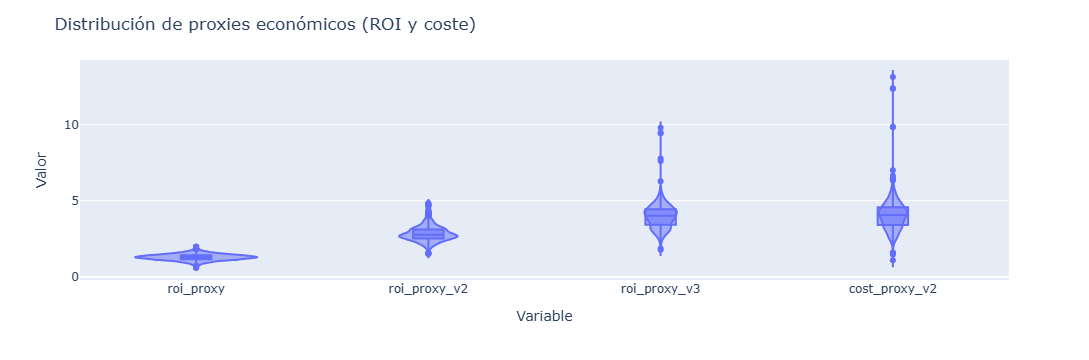

In [9]:
# Distribución de las variables de tipo ROI y proxies (Calculadas)

# Variables continuas
roi_continuous_vars = [
    "roi_proxy",
    "roi_proxy_v2",
    "roi_proxy_v3",
    "cost_proxy_v2"
]

# Pasamos a formato largo (long / tidy)
df_long = df_tablon[roi_continuous_vars].melt(
    var_name="variable",
    value_name="value"
)

fig = px.violin(
    df_long,
    x="variable",
    y="value",
    box=True,          # muestra boxplot interno
    # points="all",      # muestra puntos individuales
)

fig.update_layout(
    title="Distribución de proxies económicos (ROI y coste)",
    xaxis_title="Variable",
    yaxis_title="Valor",
    violingap=0.25,
)

fig.show()

Observamos que la variable **`roi_proxy`** presenta una distribución aproximadamente simétrica, con la media y la mediana próximas entre sí y situadas en la zona central del rango de valores, lo que indica que la mayoría de las patentes concentran valores de ROI en torno a niveles intermedios.
 
Mientras que tanto **`roi_proxy_v3`** y **`cost_proxy_v2`** tienen una distribución sesgada a la derecha, con varios outliers situados en los valores altos (entre 7 y 15), esto quiere decir que Muchas patentes con retorno modesto y pocas con retorno muy alto. **`roi_proxy_v2`**.

La transformación introducida en **`roi_proxy_v2`** reduce significativamente la asimetría de la distribución, limitando la influencia de valores extremos sin eliminar la diferenciación entre patentes de alto y bajo valor.

### Distribución de variables discrtas ROI

Distribución de **`roi_proxy`** con respecto a **`roi_class`**

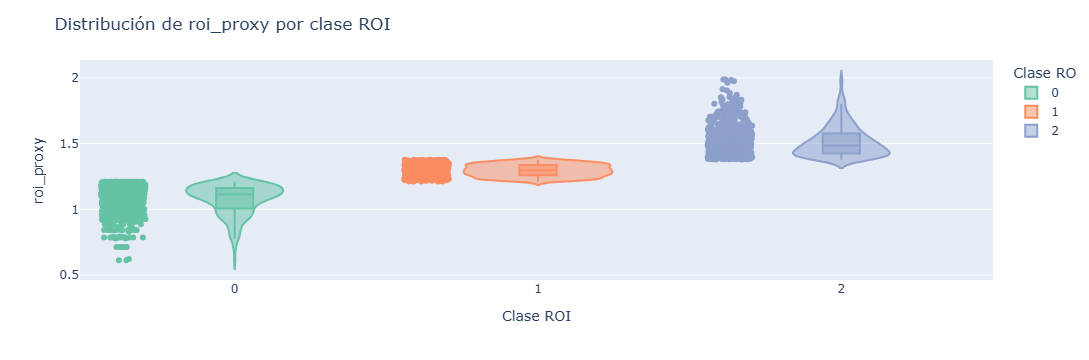

In [10]:
fig = px.violin(
    df_tablon,
    x="roi_class",
    y="roi_proxy",
    color="roi_class",  # ← clave para el colormap
    box=True,
    points="all",
    category_orders={
        "roi_class": sorted(df_tablon["roi_class"].dropna().unique())
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    title="Distribución de roi_proxy por clase ROI",
    xaxis_title="Clase ROI",
    yaxis_title="roi_proxy",
    legend_title="Clase ROI"
)

fig.show()

La figura muestra la distribución del `roi_proxy` por clase ROI. Se observa una separación clara y monotónica entre las clases, con un desplazamiento progresivo de las distribuciones hacia valores más altos a medida que aumenta la clase.

Esto indica que la discretización del ROI es coherente con el proxy continuo y que el indicador captura adecuadamente distintos niveles de retorno estimado.

Distribución de **`roi_proxy_v3`** con respecto a **`roi_class`**

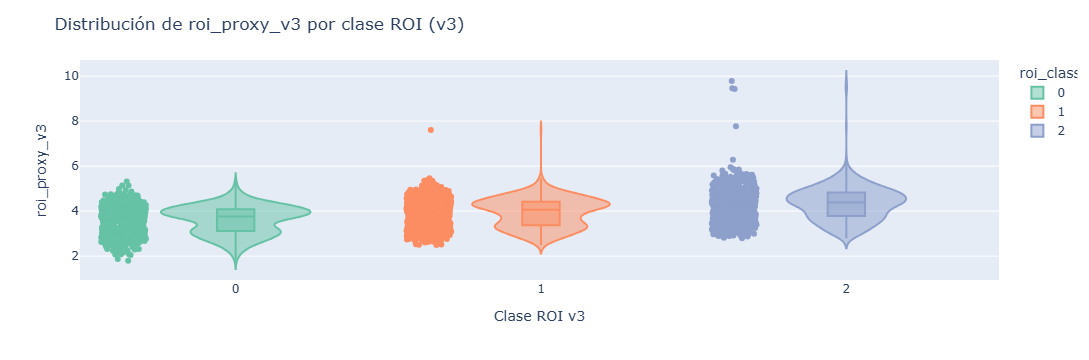

In [11]:
fig = px.violin(
    df_tablon,
    x="roi_class",
    y="roi_proxy_v3",
    color="roi_class",  # ← clave para el colormap
    box=True,
    points="all",
    category_orders={
        "roi_class": sorted(df_tablon["roi_class"].dropna().unique())
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    title="Distribución de roi_proxy_v3 por clase ROI (v3)",
    xaxis_title="Clase ROI v3",
    yaxis_title="roi_proxy_v3"
)

fig.show()

Análogamente a lo ateriormente expuesto:

La figura muestra la distribución del `roi_proxy_v3` por clase ROI_v3. Se observa una separación clara y monotónica entre las clases, con un desplazamiento progresivo de las distribuciones hacia valores más altos a medida que aumenta la clase.

Esto indica que la discretización del ROI es coherente con el proxy continuo y que el indicador captura adecuadamente distintos niveles de retorno estimado.

## Variables Actores de la patente (complejidad organizativa):

### Historigramas y correlación entre variabñes de la agrupación (Solicitantes e inventores vs ROI)

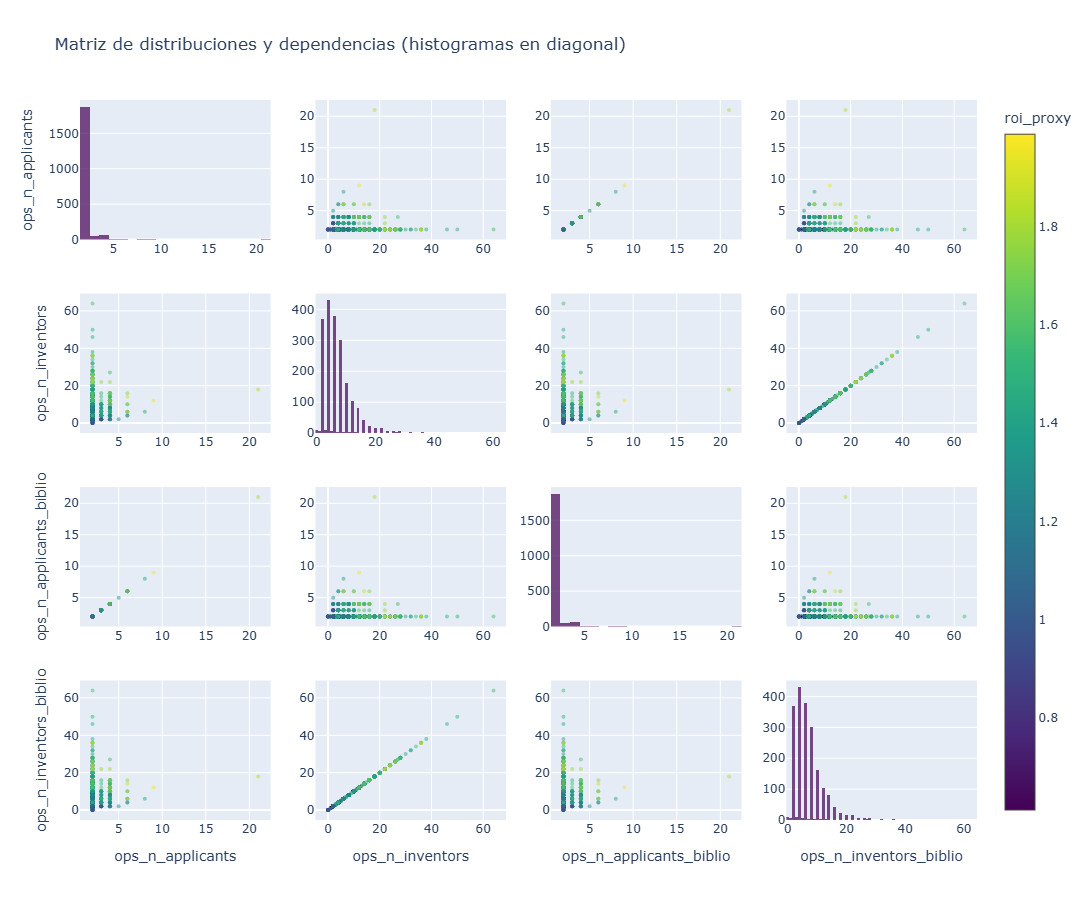

In [12]:
cols = [
    "ops_n_applicants",
    "ops_n_inventors",
    "ops_n_applicants_biblio",
    "ops_n_inventors_biblio",
]

df = df_tablon[cols + ["roi_proxy"]].dropna()
n = len(cols)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols):
    for j, x in enumerate(cols):

        # Diagonal → histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(
                        color="rgba(68,1,84,0.7)"
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal → scatter
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# 🔹 ETIQUETAS DE EJES
for i, col in enumerate(cols):
    # Eje Y (primera columna)
    fig.update_yaxes(
        title_text=col,
        row=i+1,
        col=1
    )

    # Eje X (última fila)
    fig.update_xaxes(
        title_text=col,
        row=n,
        col=i+1
    )

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias (histogramas en diagonal)",
)

fig.show()


## Matriz de distribuciones y dependencias entre solicitantes e inventores

La figura anterior muestra una **matriz de distribuciones y dependencias** entre las siguientes variables:

- `ops_n_applicants`: número de solicitantes (fuente OPS)
- `ops_n_inventors`: número de inventores (fuente OPS)
- `ops_n_applicants_biblio`: número de solicitantes (fuente bibliográfica)
- `ops_n_inventors_biblio`: número de inventores (fuente bibliográfica)

La matriz se interpreta de la siguiente forma:

---

### 🔹 Diagonal principal: histogramas (distribuciones marginales)

En la diagonal se representan **histogramas univariantes**, que permiten analizar la forma de la distribución de cada variable de manera individual.

Observaciones principales:

- Todas las variables presentan una **distribución fuertemente asimétrica a la derecha**.
- La mayor parte de las patentes tienen:
  - Muy pocos solicitantes (1–3)
  - Muy pocos inventores (1–5)
- Existen **colas largas** con valores elevados, correspondientes a:
  - Grandes empresas
  - Proyectos colaborativos
  - Patentes complejas o consorcios internacionales

Este comportamiento justifica:
- El uso de **transformaciones logarítmicas**
- El tratamiento cuidadoso de **outliers**
- El uso de estadísticas robustas (mediana, IQR)

---

### 🔹 Fuera de la diagonal: relaciones bivariantes

Las celdas fuera de la diagonal muestran **gráficos de dispersión** entre pares de variables.

Cada punto representa una patente y está coloreado según el valor de `roi_proxy`, usando un **colormap secuencial**, lo que permite observar si existe alguna relación visual entre complejidad estructural y retorno económico estimado.

#### Relaciones destacadas:

- **`ops_n_inventors` vs `ops_n_inventors_biblio`**
  - Relación prácticamente **lineal perfecta**
  - Indica una alta coherencia entre ambas fuentes de datos
  - Sugiere **redundancia informativa** entre estas variables

- **`ops_n_applicants` vs `ops_n_applicants_biblio`**
  - Relación positiva clara, aunque con mayor dispersión
  - Posibles diferencias de normalización entre fuentes

- **Solicitantes vs inventores**
  - Relación positiva débil–moderada
  - Aumentar el número de solicitantes no implica necesariamente un aumento proporcional del número de inventores
  - Refleja distintos modelos de organización de la innovación

---

### 🔹 Interpretación económica (color por `roi_proxy`)

El coloreado por `roi_proxy` sugiere que:

- Patentes con mayor número de inventores o solicitantes tienden a mostrar valores más altos del proxy de retorno, aunque:
  - La relación no es estrictamente lineal
  - Existe una gran variabilidad dentro de cada rango

Esto indica que el tamaño o complejidad organizativa **no es suficiente por sí sola** para explicar el retorno económico, reforzando la necesidad de modelos multivariantes.

---

### 🔹 Conclusiones clave

- Las variables presentan **distribuciones no normales** y colas largas.
- Existen **dependencias fuertes** entre variables equivalentes de distintas fuentes (OPS vs bibliografía).
- Se detecta **colinealidad**, lo que sugiere:
  - Seleccionar una sola variable representativa por pareja
  - O aplicar técnicas de reducción de dimensionalidad
- El análisis visual apoya el uso de:
  - Transformaciones log
  - Modelos robustos
  - Regularización para evitar redundancia

Esta matriz proporciona una visión exploratoria fundamental previa a la construcción de modelos predictivos del retorno de las patentes.


## Variables de Clasificación tecnológica (IPC / CPC):

### Historigrama y correlación de las variables discretas y comparativa vs roi_proxy

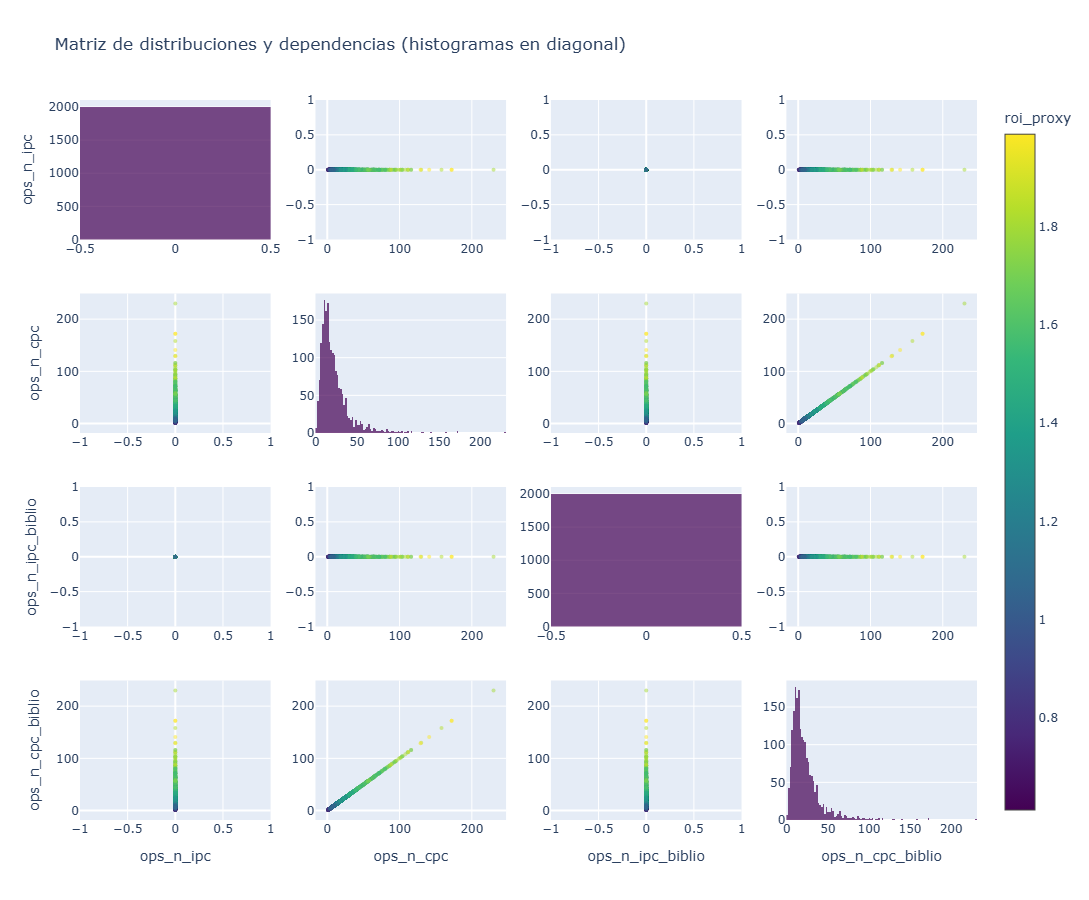

In [13]:
cols = [
    "ops_n_ipc",
    "ops_n_cpc",
    "ops_n_ipc_biblio",
    "ops_n_cpc_biblio",
]

df = df_tablon[cols + ["roi_proxy"]].dropna()
n = len(cols)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols):
    for j, x in enumerate(cols):

        # Diagonal → histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(
                        color="rgba(68,1,84,0.7)"
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal → scatter
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# 🔹 ETIQUETAS DE EJES
for i, col in enumerate(cols):
    # Eje Y (primera columna)
    fig.update_yaxes(
        title_text=col,
        row=i+1,
        col=1
    )

    # Eje X (última fila)
    fig.update_xaxes(
        title_text=col,
        row=n,
        col=i+1
    )

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias (histogramas en diagonal)",
)

fig.show()


### Historigrama y correlación de las variables discretas y comparativa vs roi_proxy_v3

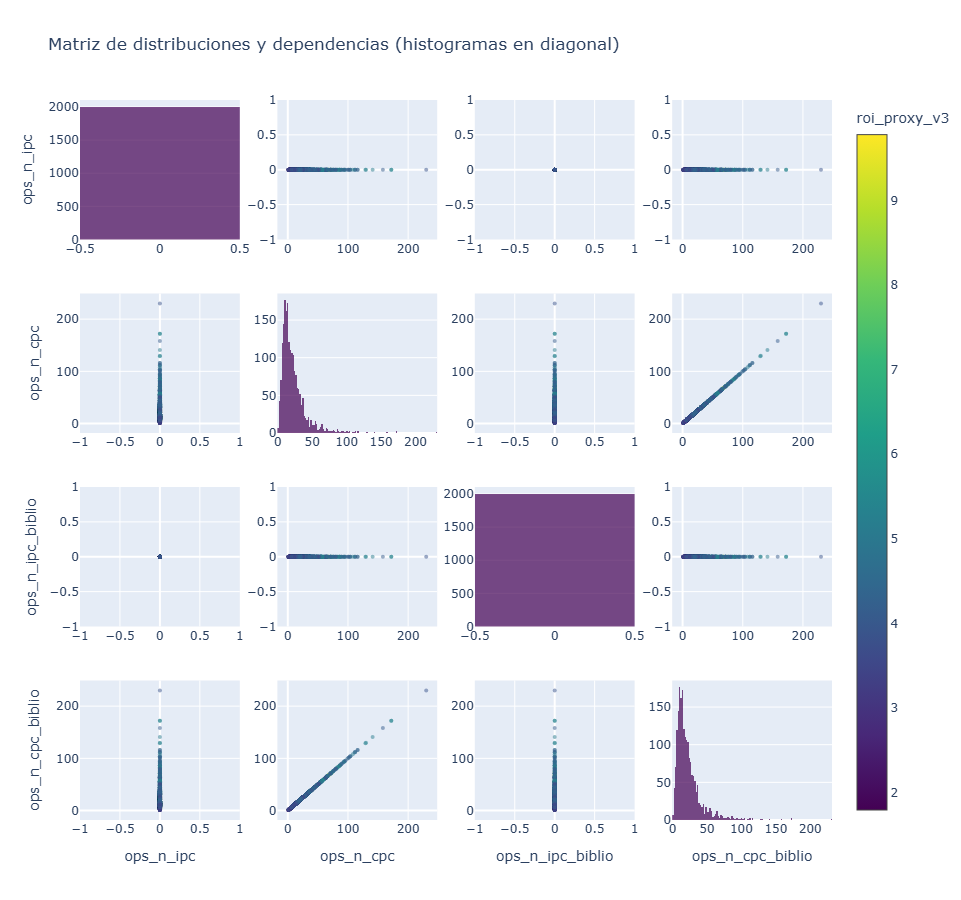

In [14]:
cols = [
    "ops_n_ipc",
    "ops_n_cpc",
    "ops_n_ipc_biblio",
    "ops_n_cpc_biblio",
]

df = df_tablon[cols + ["roi_proxy_v3"]].dropna()
n = len(cols)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols):
    for j, x in enumerate(cols):

        # Diagonal → histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(
                        color="rgba(68,1,84,0.7)"
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal → scatter
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# 🔹 ETIQUETAS DE EJES
for i, col in enumerate(cols):
    # Eje Y (primera columna)
    fig.update_yaxes(
        title_text=col,
        row=i+1,
        col=1
    )

    # Eje X (última fila)
    fig.update_xaxes(
        title_text=col,
        row=n,
        col=i+1
    )

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias (histogramas en diagonal)",
)

fig.show()


### Interpretación de la matriz usando `roi_proxy` y `roi_proxy_v3`

Al repetir el análisis empleando `roi_proxy` y `roi_proxy_v3` como variable de color, se observan diferencias relevantes entre dichos análisis, lo que permite profundizar en la interpretación económica de las variables tecnológicas.

---

#### 🔹 1. Los códigos IPC siguen sin aportar variabilidad explicativa

De forma consistente con el análisis anterior, las variables:

- `ops_n_ipc`
- `ops_n_ipc_biblio`

presentan una distribución extremadamente concentrada, con muy poca variabilidad efectiva.

Además:
- El coloreado por `roi_proxy` no revela ningún gradiente significativo.
- Estas variables se comportan prácticamente como constantes.

Por tanto, se confirma que **el número de códigos IPC no es un buen descriptor ni de complejidad técnica ni de retorno económico**, independientemente del proxy de ROI utilizado.

---

#### 🔹 2. Los códigos CPC capturan esfuerzo tecnológico y alcance

A diferencia del análisis con `roi_proxy_v3`, al utilizar `roi_proxy` se observa que:

- Las variables `ops_n_cpc` y `ops_n_cpc_biblio` muestran un **ligero gradiente de color**.
- Patentes con un mayor número de códigos CPC tienden a presentar valores más altos de `roi_proxy`.

Esto sugiere que:
- El número de CPC está relacionado con **esfuerzo tecnológico**, amplitud de clasificación y alcance técnico.
- `roi_proxy` captura parcialmente estas dimensiones estructurales.

No obstante, la dispersión sigue siendo elevada, lo que indica que esta relación es **débil y no determinista**.

---

#### 🔹 3. Diferencia conceptual entre ambos proxies de ROI

La comparación entre ambas matrices pone de manifiesto que:

- `roi_proxy` es sensible a variables de **complejidad y despliegue tecnológico**.
- `roi_proxy_v3`, al introducir penalizaciones por coste y normalización temporal, **elimina esta correlación**, reteniendo únicamente relaciones más directamente ligadas a eficiencia económica.

Este comportamiento valida el refinamiento progresivo del proxy, mostrando cómo versiones más sofisticadas reducen correlaciones espurias.

---

#### 🔹 4. Redundancia entre fuentes de datos

Se mantiene una relación prácticamente perfecta entre:
- `ops_n_cpc` y `ops_n_cpc_biblio`
- `ops_n_ipc` y `ops_n_ipc_biblio`

Lo que confirma que:
- Ambas fuentes contienen información equivalente para estas variables.
- La inclusión simultánea de ambas introduce colinealidad sin ganancia informativa.
- Es preferible seleccionar una única fuente por tipo de variable.

---

#### 🔹 5. Implicaciones para el modelado

A partir de este análisis se concluye que:

- `ops_n_ipc` y `ops_n_ipc_biblio` pueden descartarse del modelo.
- Solo una de las variables CPC debería mantenerse.
- El número bruto de códigos CPC puede ser útil como descriptor de **esfuerzo tecnológico**, pero no como proxy directo de retorno económico.
- Resulta más adecuado emplear **proxies derivados**, como medidas de diversidad o amplitud tecnológica, especialmente si el objetivo es aproximar eficiencia económica.

---

#### 🔹 6. Valor añadido del análisis comparativo

La comparación entre `roi_proxy` y `roi_proxy_v3` permite:
- Distinguir entre variables que explican **tamaño, alcance o complejidad**
- Y aquellas que explican **retorno neto ajustado por costes**

Este enfoque refuerza la solidez metodológica del estudio y justifica el uso de proxies refinados en fases avanzadas del modelado.


La variable **`tech_breadth_proxy`** constituye un proxy continuo derivado que permite capturar de forma cuantitativa la amplitud tecnológica de cada patente, resultando más adecuado para el análisis estadístico y la modelización.

## Cálculo de **`tech_breadth_proxy`**:

Con el fin de capturar de forma robusta la diversidad o amplitud tecnológica de una patente, se define el proxy `tech_breadth_proxy`.

### Definición

Definimos:

$$
tech\_breadth\_proxy = \log(1 + ops\_n\_cpc)
$$

Esta transformación:

- Captura amplitud tecnológica de forma agregada.
- Reduce el impacto de valores extremos (colas largas).
- Facilita comparaciones entre patentes.

<code>
    import numpy as np
    df_tablon["tech_breadth_proxy"] = np.log1p(df_tablon["ops_n_cpc"])
    df_tablon[["ops_n_cpc", "tech_breadth_proxy"]].head()
</code>

### Exclusión de `tech_breadth_proxy`

La variable `tech_breadth_proxy` se excluye del análisis independiente porque **actúa como un proxy intermedio utilizado en la construcción del `proxy_roi`**.

Dado que `tech_breadth_proxy` sintetiza información tecnológica que ya contribuye directamente al valor del proxy de retorno, su uso adicional como feature produciría **fuga de información (target leakage)** y sesgaría la evaluación del modelo.

Por este motivo, `tech_breadth_proxy` se considera **endógena al objetivo** y se excluye deliberadamente del conjunto de variables analizadas.

## Variables de clasificación tecnológica (IPC / CPC)

El análisis de la dimensión tecnológica del conjunto de datos se ha visto condicionado por varias limitaciones estructurales en las variables de clasificación IPC/CPC disponibles. En particular, los campos correspondientes al código IPC principal (`ops_ipc_main` y `ops_ipc_main_biblio`) no contienen valores informados, mientras que el número de códigos IPC (`ops_n_ipc` y `ops_n_ipc_biblio`) presenta una variabilidad muy reducida, lo que limita su capacidad descriptiva y predictiva.

Por este motivo, dichas variables no resultan adecuadas para su inclusión directa en el análisis ni en el modelado posterior.

En su lugar, se ha definido y empleado el proxy **`tech_breadth_proxy`**, concebido como una medida agregada de amplitud tecnológica basada en el número de códigos CPC asignados a cada patente. Este proxy captura de forma continua y robusta la diversidad del espacio tecnológico cubierto, evitando el uso de etiquetas categóricas inexistentes y reduciendo el impacto de colas largas mediante una transformación logarítmica.

Los contrastes empíricos realizados muestran que `tech_breadth_proxy` presenta una asociación estadísticamente significativa tanto con `roi_proxy` como con `roi_proxy_v3`, aunque con distinta magnitud. Este resultado indica que la amplitud tecnológica constituye un factor relevante para explicar proxies estructurales de retorno y mantiene una relación moderada con proxies de retorno económico más ajustados.

Dado que no se dispone de información adicional sobre la estructura jerárquica de los códigos IPC/CPC (por ejemplo, listas completas de códigos por patente), no es posible construir métricas más avanzadas de diversidad o concentración tecnológica. En consecuencia, `tech_breadth_proxy` se considera una representación adecuada y suficiente de la dimensión tecnológica en el contexto del presente estudio, y se incorpora como única variable de esta categoría en el modelo, evitando redundancias y el uso de información no disponible.


## Variables de Familia de patentes y estrategia internacional

La familia de patentes constituye una dimensión clave para aproximar la **estrategia internacional y el esfuerzo de protección** asociado a una invención. A diferencia de las variables puramente tecnológicas, las variables de familia reflejan decisiones estratégicas del solicitante relativas a la extensión geográfica, el alcance jurídico y la expectativa de explotación económica de la patente.

En términos generales, una familia de mayor tamaño y con presencia en múltiples jurisdicciones suele implicar:
- un mayor coste económico de tramitación y mantenimiento,
- una expectativa de mercado más amplia,
- y una mayor relevancia estratégica de la invención.

Por este motivo, las variables de familia se consideran proxies indirectos del valor percibido de la patente por parte del solicitante.

---

### Variables de familia disponibles

El conjunto de datos incluye las siguientes variables relacionadas con la familia de patentes:

- `family_size_simple`: número total de documentos que componen la familia.
- `family_country_count_simple`: número de países distintos en los que se ha extendido la protección.
- `family_kinds_count_simple`: número de tipos de documento (kinds) dentro de la familia.

Estas variables capturan distintos aspectos de la estrategia internacional:

- `family_size_simple` refleja la **intensidad global de protección**.
- `family_country_count_simple` mide explícitamente el **alcance geográfico**.
- `family_kinds_count_simple` aproxima la **complejidad procedimental y jurídica** de la familia.


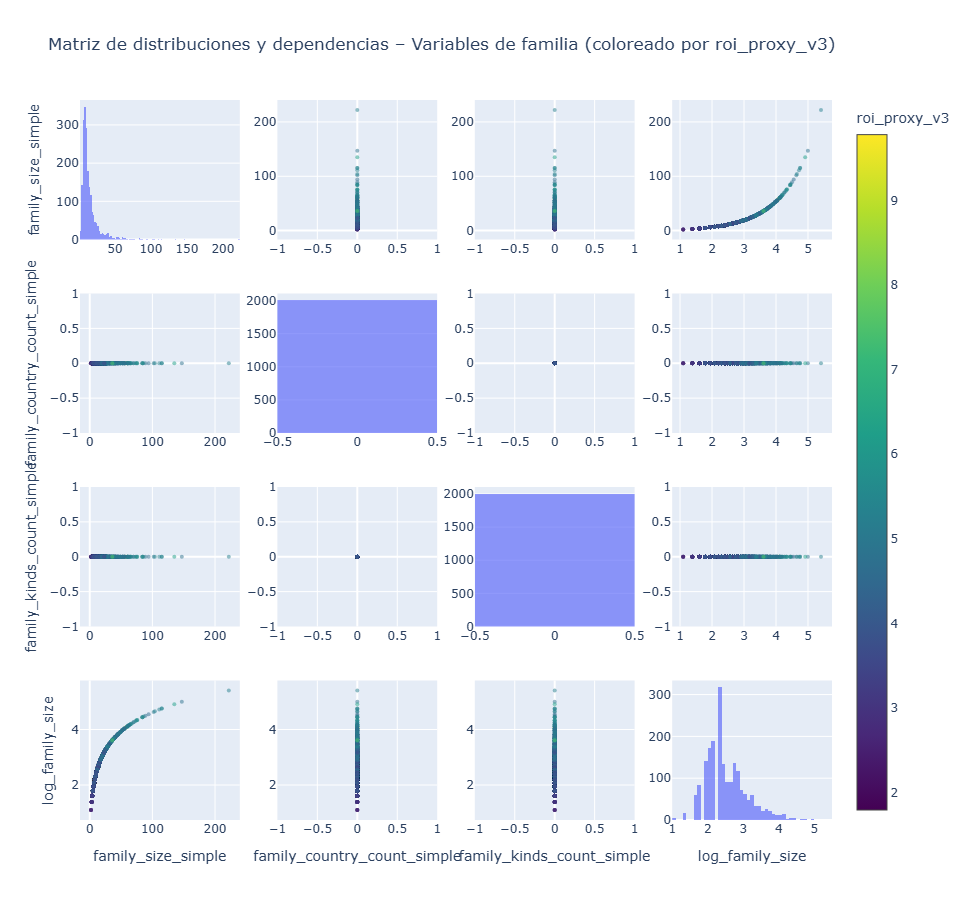

In [15]:
cols_family = [
    "family_size_simple",
    "family_country_count_simple",
    "family_kinds_count_simple",
    "log_family_size",
]

df = df_tablon[cols_family + ["roi_proxy_v3"]].dropna()
n = len(cols_family)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols_family):
    for j, x in enumerate(cols_family):

        # Diagonal: histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(color="rgba(99,110,250,0.7)"),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal: scatter con colormap ROI
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# Etiquetas de ejes
for i, col in enumerate(cols_family):
    fig.update_yaxes(title_text=col, row=i+1, col=1)
    fig.update_xaxes(title_text=col, row=n, col=i+1)

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias – Variables de familia (coloreado por roi_proxy_v3)"
)

fig.show()


La anterior figura: presenta una matriz de distribuciones y dependencias entre las variables de familia de patentes, con el retorno económico ajustado (`roi_proxy_v3`) representado mediante un colormap. La diagonal muestra las distribuciones marginales, mientras que las celdas fuera de la diagonal permiten evaluar tanto la colinealidad entre métricas de familia como su asociación con el ROI. Esta visualización conjunta permite identificar redundancias, detectar relaciones no lineales y evaluar de forma exploratoria la relevancia económica de cada variable.

Podemos ver que tanto **´family_country_count_simple´** como  **´family_kinds_count_simple´** no aportan variablidad al modelo, ya que son valores fijos.

Por otro lado como **´log_family_size´** y **´family_size_simple´** están relaccionados de la siguiente forma:

Se define la variable `log_family_size` como:

$$
\text{log\_family\_size}
=
\log\!\left( 1 + \text{family\_size\_simple} \right)
$$


Seleccionamos la variable **´log_family_size´** como posible predictora para el modelo final.

### Exclusión de `log_family_size` y `family_size_simple`

La variable `log_family_size` no se analiza de forma independiente porque **forma parte explícita de la fórmula de cálculo del `proxy_roi`**.

Dado que `proxy_roi` incluye el tamaño de la familia de patentes (transformado logarítmicamente) como uno de sus componentes, analizar `log_family_size` por separado introduciría:

- Redundancia informativa.
- Colinealidad estructural con la variable objetivo.
- Sesgo en la interpretación de la importancia de las variables.

Por este motivo, `log_family_size` se considera **endógena al `proxy_roi`** y se excluye deliberadamente del conjunto de variables analizadas de forma independiente.

Por otro lado la variable `family_size_simple` no se analiza de forma independiente porque **forma parte directa de la definición del proxy de retorno (`proxy_roi`)**.

Dado que el tamaño de la familia de patentes es uno de los componentes estructurales utilizados para aproximar el impacto y el valor potencial de una invención, su inclusión como variable explicativa adicional introduciría **redundancia informativa** y **colinealidad estructural** con la variable objetivo.

Por este motivo, `family_size_simple` se considera **endógena al proxy de ROI** y se excluye deliberadamente del análisis independiente.


El análisis de las variables de familia muestra que `family_country_count_simple` presenta un valor constante igual a cero en todo el conjunto de datos, lo que indica ausencia de variabilidad y descarta su uso como variable explicativa. Asimismo, `family_kinds_count_simple` no muestra una asociación clara con el ROI una vez considerado el tamaño de la familia.


## Variables de Eventos legales y estado jurídico

### Motivación

Los eventos legales asociados a una patente reflejan su **trayectoria jurídica a lo largo del tiempo** y constituyen una fuente clave de información sobre su grado de explotación, defensa y conflicto. A diferencia de las variables tecnológicas o de familia, que capturan decisiones ex ante del solicitante, los eventos legales proporcionan información **ex post**, ligada al ciclo de vida real de la patente.

Desde un punto de vista económico, una mayor actividad legal puede interpretarse como:
- mayor esfuerzo de mantenimiento y defensa,
- mayor interés estratégico en la patente,
- o mayor exposición a conflictos y disputas.

Por este motivo, las variables legales se consideran proxies indirectos tanto de **valor económico** como de **riesgo jurídico**.

---

### Variables legales disponibles

El conjunto de datos incluye las siguientes variables relacionadas con eventos legales y estado jurídico:

- `legal_events_count`: número total de eventos legales registrados para la patente.
- `legal_codes_unique`: número de códigos legales distintos asociados a dichos eventos.
- `legal_first_date`: fecha del primer evento legal registrado.
- `legal_last_date`: fecha del último evento legal registrado.
- `legal_has_grant_like`: indicador binario de concesión o evento equivalente.
- `legal_has_opposition_like`: indicador binario de oposición, revocación o conflicto.
- `legal_missing_dates`: número de eventos legales sin fecha válida.

Estas variables permiten caracterizar tanto la **intensidad** como la **naturaleza** de la actividad legal asociada a cada patente.

---

### Interpretación conceptual de las variables

- **Intensidad legal**
  - `legal_events_count` y `legal_codes_unique` miden el volumen y la diversidad de actividad jurídica.
  - Valores elevados indican patentes con ciclos de vida activos y potencialmente costosos de mantener.

- **Trayectoria temporal**
  - `legal_first_date` y `legal_last_date` permiten reconstruir la duración y vigencia del historial legal.
  - La diferencia entre ambas fechas aproxima la **vida jurídica observada** de la patente.

- **Estado jurídico clave**
  - `legal_has_grant_like` identifica patentes que han alcanzado un hito jurídico relevante (concesión).
  - `legal_has_opposition_like` captura la existencia de conflictos, oposiciones o disputas.

- **Calidad del dato**
  - `legal_missing_dates` actúa como indicador de incompletitud o ruido en el historial legal, relevante para evaluar la fiabilidad de las variables temporales.

---

### Análisis gráfico variables legales

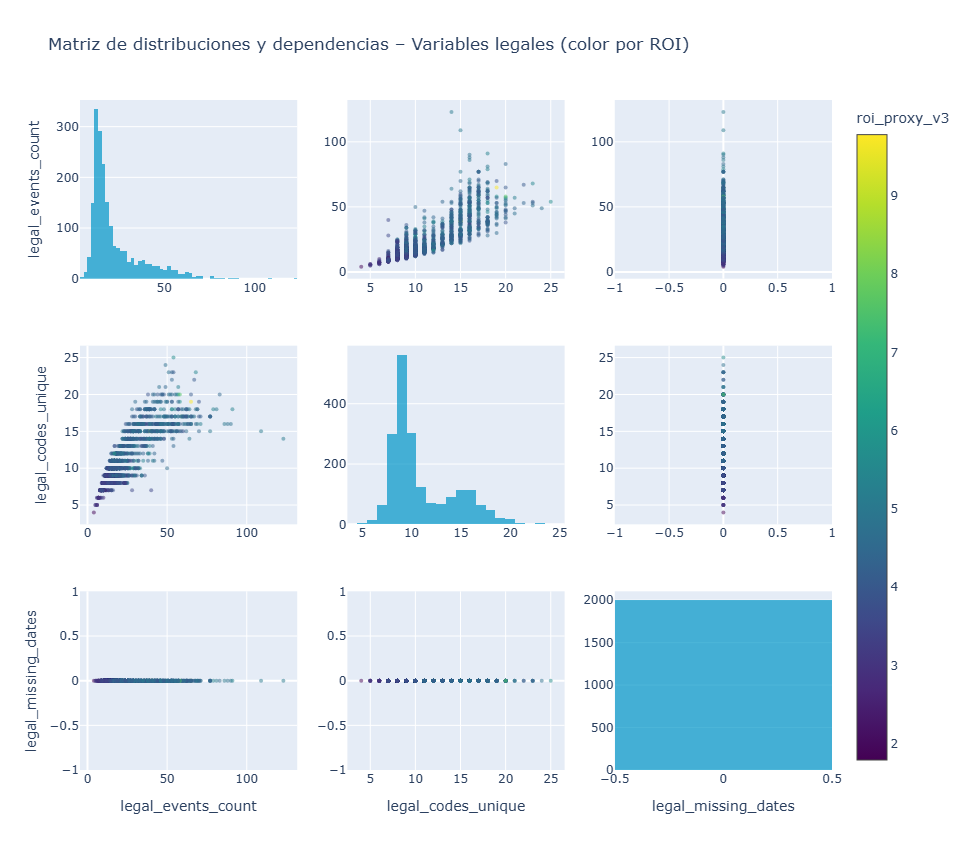

In [16]:
legal_vars = [
    "legal_events_count",
    "legal_codes_unique",
    "legal_missing_dates",
]

df = df_tablon[legal_vars + ["roi_proxy_v3"]].dropna()
n = len(legal_vars)

fig = make_subplots(rows=n, cols=n)

for i, y in enumerate(legal_vars):
    for j, x in enumerate(legal_vars):

        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(color="rgba(0,150,200,0.7)"),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

for i, col in enumerate(legal_vars):
    fig.update_yaxes(title_text=col, row=i+1, col=1)
    fig.update_xaxes(title_text=col, row=n, col=i+1)

fig.update_layout(
    height=850,
    width=850,
    title="Matriz de distribuciones y dependencias – Variables legales (color por ROI)"
)

fig.show()


### Interpretación gráfica:

Las dos variables: **´legal_events_count´**, **´legal_codes_unique´** muestran variabilidad con distribuciones distintas, en ambos casos, mientras que **´legal_events_count´** parece una distribución sesgada a la derecha, en cambio **´legal_codes_unique´** se asemeja a una bimodal.

Por el contrario **´legal_missing_dates´** no aporta información al modelo.

Observamos a su vez que a priori tanto **´legal_events_count´**, **´legal_codes_unique´** tienen capacidad explicativa sobre la variablidad del proxy_roi_v3. En los contrastes de hipotesis siguientes comprobaremos esta realidad.

Para entender de manera gráfica los indicadores binarios utilizamos las siguientes gráficas:

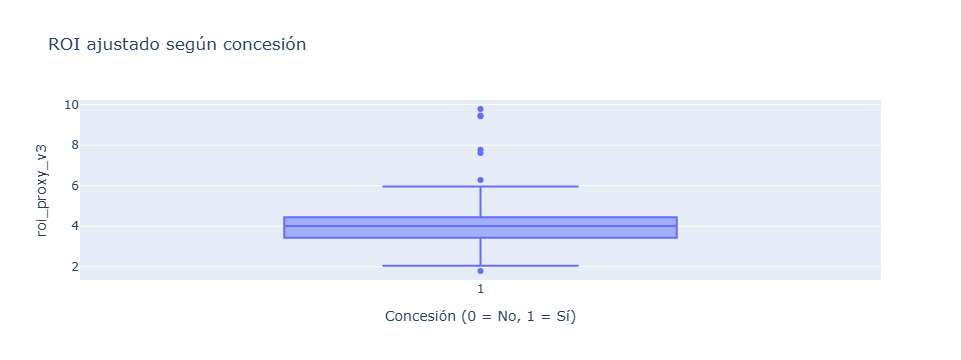

In [17]:
fig = px.box(
    df_tablon,
    x="legal_has_grant_like",
    y="roi_proxy_v3",
    title="ROI ajustado según concesión",
    labels={"legal_has_grant_like": "Concesión (0 = No, 1 = Sí)"}
)
fig.show()

La variable: **´legal_has_grant_like´** no ofrece ninguna explicación sobre proxy_roi_v3, por lo que la podemos descartar del modelo final.

In [18]:
fig = px.box(
    df_tablon,
    x="legal_has_opposition_like",
    y="roi_proxy_v3",
    title="ROI ajustado según oposición",
    labels={"legal_has_opposition_like": "Oposición (0 = No, 1 = Sí)"}
)
fig.show()


En este caso **´legal_has_opposition_like´** presenta varianza y valores repartidos para cada valor de roi_proxy_v3, con lo que a priori esta variable puede ser util para el modelo, lo corroboraremos con un contraste de hipoteis adaptado.

## Contraste de hipoteis relacción **`legal_codes_unique`** frente a ROI

### Hipótesis
Para cada proxy de ROI y para ambas variables:
- H₀: legal_codes_unique son independiente del ROI
- H₁: existe asociación monotónica entre ambas

Usamos Spearman (robusto, no asume normalidad):

### Exclusión de `legal_events_count`

La variable `legal_events_count` se excluye del análisis independiente porque **se utiliza explícitamente como componente del proxy de retorno (`proxy_roi`)**, al capturar la intensidad y evolución jurídica del expediente.

Incluir esta variable como feature adicional implicaría analizar dos veces el mismo factor subyacente, generando **dependencia determinista** con la variable objetivo y comprometiendo la interpretación de los resultados.

Por tanto, `legal_events_count` se considera **parte constitutiva del proxy de ROI** y no se incorpora como variable explicativa independiente.


### Exclusión de `legal_codes_unique`

La variable `legal_codes_unique` no se analiza de forma independiente porque **interviene directamente en el cálculo del proxy de retorno (`proxy_roi`)**, representando la diversidad de eventos legales asociados a la patente.

Su inclusión como variable explicativa introduciría **colinealidad estructural** y **sobreponderación artificial** del componente legal dentro del modelo, al reforzar un factor ya incorporado en la variable objetivo.

En consecuencia, `legal_codes_unique` se excluye del análisis como variable independiente.

## Contraste de hipoteis relacción **`legal_has_opposition_like`** frente a ROI

### Hipótesis
Para **`legal_has_opposition_like`** con respecto a proxy_roi_v3:
- H₀: La distribución de ROI es la misma para patentes con y sin oposición.
- H₁: Las distribuciones son distintas.

Usamos el método de Mann–Whitney U:
(*) No asumimos normalidad → test no paramétrico.

In [19]:
# separar grupos
group_0 = df_tablon.loc[
    df_tablon["legal_has_opposition_like"] == 0,
    "roi_proxy_v3"
].dropna()

group_1 = df_tablon.loc[
    df_tablon["legal_has_opposition_like"] == 1,
    "roi_proxy_v3"
].dropna()

# test Mann–Whitney
u_stat, p_value = mannwhitneyu(
    group_0,
    group_1,
    alternative="two-sided"
)


print(
    f"""
Test Mann–Whitney -U
u_stat: {u_stat},
pvalue: {p_value}, 
    """)

ks_stat, p_value_ks = ks_2samp(group_0, group_1)

print(f"""
Test Kolmogorov–Smirnov (KS)
ks_stat: {ks_stat}
p_value_ks {p_value_ks}
""")



Test Mann–Whitney -U
u_stat: 49599.0,
pvalue: 2.6694290679703875e-13, 
    

Test Kolmogorov–Smirnov (KS)
ks_stat: 0.4026972692243257
p_value_ks 1.3081355975904625e-13



La relevancia de las variables legales binarias se ha evaluado mediante contrastes no paramétricos, comparando la distribución del ROI entre patentes con y sin determinados eventos jurídicos. En particular, se ha aplicado el test de Mann–Whitney U para contrastar la hipótesis nula de igualdad de distribuciones, complementado con el test de Kolmogorov–Smirnov para evaluar diferencias en la forma global de la distribución. Este enfoque permite evaluar la significación económica de eventos como la oposición o la concesión sin asumir normalidad ni linealidad.

Del contraste de hipóteis usando el **Test Mann–Whitney -U** anterior podemos observar que dado a que p_value < 0.05 es sufuciente razón para rechazar la hipótesis nula.

Concluimos con la acepetación de la hipóteis alternativa es decir: Las distribuciones para los dintintos valores de **`legal_has_opposition_like`** son diferentes con lo que la variable es estadisticamente relevante para la explciación del ROI.

Por otro lado y gracias a la corroboración usando el **Test Kolmogorov–Smirnov (KS)**, podemos inferir lo siguiente, dado que p_value_ks sigue siendo menor que 0.05, aseguramos la variable `legal_has_opposition_like` se considera relevante desde el punto de vista estadístico y se incorpora como candidata explicativa en el análisis posterior.

### Proxy obtenido de las fechas legales: **`legal_mid_date`**, **`mid_to_pub_days`** y **`alignment_score`**

## Proxies temporales basados únicamente en fechas legales

Estos proxies se construyen **exclusivamente** a partir de:

- `legal_first_date`
- `legal_last_date`

No utilizan ninguna referencia temporal externa (fecha actual,
fecha de publicación, etc.), lo que garantiza que no introducen
*leakage temporal* en modelos predictivos.

Cada proxy se calcula fila a fila mediante funciones puras aplicadas
con `DataFrame.apply(axis=1)`.

---

### Proxy 1 — Delta legal (duración de actividad)

Mide la duración total del intervalo legal:

$$
\Delta t = | legal\_last\_date - legal\_first\_date |
$$

- Captura la “vida legal” del activo.
- Valores altos indican actividad sostenida en el tiempo.

---

### Proxy 2 — Delta suavizado (log-life)

Para evitar colas largas se aplica una transformación logarítmica:

$$
\text{delta\_log} = \log(1 + \Delta t)
$$

- Más estable para modelos lineales y regularizados.
- Escala comparable entre familias muy distintas.

---

### Proxy 3 — Vida compacta (intensidad temporal)

Favorece actividad legal concentrada y penaliza intervalos excesivamente largos:

$$
\text{compact\_life} = \frac{\log(1 + \Delta t)}{1 + \Delta t}
$$

- Máximo para duraciones cortas–medias.
- Útil como señal de gestión activa.



In [20]:
# --- Proxy 1: delta simple ---
delta_days = lambda r: (
    abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days)
    if pd.notna(r.iloc[0]) and pd.notna(r.iloc[1])
    else np.nan
)

df = df_tablon.copy()
df["legal_delta_days"] = df[
    ["legal_first_date", "legal_last_date"]
].apply(delta_days, axis=1)


# --- Proxy 2: delta log ---
delta_log = lambda r: (
    np.log1p(abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days))
    if pd.notna(r.iloc[0]) and pd.notna(r.iloc[1])
    else np.nan
)

df["legal_delta_log"] = df[
    ["legal_first_date", "legal_last_date"]
].apply(delta_log, axis=1)


# --- Proxy 3: vida compacta ---
compact_life = lambda r: (
    np.log1p(abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days))
    / (1 + abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days))
    if pd.notna(r.iloc[0]) and pd.notna(r.iloc[1])
    else np.nan
)

df["legal_compact_life"] = df[
    ["legal_first_date", "legal_last_date"]
].apply(compact_life, axis=1)

In [21]:
def spearman_test(df, x, y="roi_proxy"):
    data = df[[x, y]].dropna()
    rho, p = spearmanr(data[x], data[y])
    return {
        "proxy": x,
        "spearman_rho": rho,
        "p_value": p,
        "n": len(data)
    }

proxies = [
    "legal_delta_days",
    "legal_delta_log",
    "legal_compact_life"
]

results_spearman = pd.DataFrame(
    [spearman_test(df, p) for p in proxies]
)

results_spearman


,proxy,spearman_rho,p_value,n
0,legal_delta_days,-0.05349,0.016767,1999
1,legal_delta_log,-0.05349,0.016767,1999
2,legal_compact_life,0.05349,0.016767,1999


### Conclusión

Cada proxy temporal legal presenta una correlación con el proxy de ROI
cuando se analiza de forma **bivariada e independiente**.  
La magnitud de dicha correlación es **débil**, pero **estadísticamente significativa**,
lo que indica la presencia de una señal real aunque de bajo impacto individual.


### Conclusión

Aunque los proxies temporales legales muestran una correlación bivariada
estadísticamente significativa con el proxy de ROI, la magnitud del efecto es débil.
Por este motivo, se consideran señales auxiliares y no se priorizan como
variables explicativas principales en el modelo.


## Métricas temporales derivadas del historial legal

Las métricas temporales derivadas del historial legal tienen como objetivo capturar la **dinámica, persistencia y vigencia temporal** de una patente a lo largo de su ciclo de vida jurídico. A diferencia de los conteos agregados de eventos legales, estas variables incorporan explícitamente la dimensión temporal, permitiendo analizar no solo cuántos eventos se producen, sino **cuándo** y **durante cuánto tiempo** se mantiene activa la actividad legal.

Desde una perspectiva económica, la persistencia temporal de una patente suele reflejar:
- un esfuerzo sostenido de mantenimiento y defensa,
- una expectativa continuada de explotación comercial,
- y un mayor valor estratégico percibido a lo largo del tiempo.

Las variables incluidas en este grupo permiten caracterizar distintos aspectos de dicha dinámica:

- `years_since_first_legal` y `years_since_last_legal` miden la distancia temporal desde los principales hitos legales, proporcionando información sobre la madurez y la actividad reciente de la patente.
- `alive_span_days` y `alive_years` aproximan la duración total del historial legal observado, capturando la longevidad jurídica de la patente.
- `events_per_year` sintetiza la intensidad media de la actividad legal, normalizando el número de eventos por la duración del historial.
- `is_active_recent` identifica patentes con actividad legal reciente, actuando como indicador de vigencia y relevancia actual.

En conjunto, estas métricas permiten diferenciar entre patentes con actividad jurídica puntual y aquellas con una presencia legal persistente, aportando información complementaria a las variables de familia, tecnología y eventos legales agregados. Por este motivo, se consideran proxies relevantes para analizar la relación entre la trayectoria jurídica temporal y el retorno económico asociado a la patente.


In [22]:
temporal_vars = [
    "years_since_first_legal",
    "years_since_last_legal",
    "alive_span_days",
    "alive_years",
    "events_per_year",
    ]

df = df_tablon[temporal_vars + ["roi_proxy_v3"]].dropna()
n = len(temporal_vars)

fig = make_subplots(rows=n, cols=n)

for i, y in enumerate(temporal_vars):
    for j, x in enumerate(temporal_vars):

        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(color="rgba(0,150,200,0.7)"),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

for i, col in enumerate(temporal_vars):
    fig.update_yaxes(title_text=col, row=i+1, col=1)
    fig.update_xaxes(title_text=col, row=n, col=i+1)

fig.update_layout(
    height=850,
    width=850,
    title="Matriz de distribuciones y dependencias – Variables temporales (color por ROI)"
)

fig.show()


Observamos que existen variables con dependencia lineal dos a dos, como:
 - **`alive_spam_days`** y **`alive_years`**
 - **`year_since_last_legal`** y **`alive_years`**

Lo cual tiene sentido porque una es función de la otra, de estas variables habrá que quedarse con una de la pareja unicamente para el modelo, por otra parte se ve que existe varibilidad para los distintos valores de proxy_roi_v3 lo que noas una idea de que estas variables ayudan a explicar el proxy_roi_v3 por lo que incluirán en el modelo. 

## Contraste de hipoteis relacción **`is_active_recent`** frente a ROI

### Hipótesis
Para **`is_active_recent`** con respecto a proxy_roi_v3:
- H₀: La distribución de ROI es la misma para patentes con y sin oposición.
- H₁: Las distribuciones son distintas.

Usamos el método de Mann–Whitney U:
(*) No asumimos normalidad → test no paramétrico.

In [23]:
# separar grupos
group_0 = df_tablon.loc[
    df_tablon["is_active_recent"] == 0,
    "roi_proxy_v3"
].dropna()

group_1 = df_tablon.loc[
    df_tablon["is_active_recent"] == 1,
    "roi_proxy_v3"
].dropna()

# test Mann–Whitney
u_stat, p_value = mannwhitneyu(
    group_0,
    group_1,
    alternative="two-sided"
)


print(
    f"""
Test Mann–Whitney -U
u_stat: {u_stat},
pvalue: {p_value}, 
    """)

ks_stat, p_value_ks = ks_2samp(group_0, group_1)

print(f"""
Test Kolmogorov–Smirnov (KS)
ks_stat: {ks_stat}
p_value_ks {p_value_ks}
""")



Test Mann–Whitney -U
u_stat: 67750.0,
pvalue: 1.8489338974018826e-228, 
    

Test Kolmogorov–Smirnov (KS)
ks_stat: 0.7312466179653679
p_value_ks 1.4921074526761139e-246



## Texto y longitud: señales semánticas simples

Este grupo de variables recoge información básica derivada del **contenido textual** de la patente, en concreto de su título y su resumen (abstract). A diferencia de las variables tecnológicas, legales o estratégicas, estas métricas no describen decisiones administrativas ni eventos jurídicos, sino que capturan **propiedades formales del discurso técnico** utilizado para describir la invención.

El objetivo de este bloque no es analizar el significado semántico profundo del texto, sino incorporar **señales simples, cuantificables y comparables** que reflejan cómo se presenta la invención desde un punto de vista descriptivo.

---

### Variables incluidas

- `ops_title`: título de la patente.
- `ops_abstract`: resumen o abstract de la patente.
- `title_len`: longitud del título, medida como número de caracteres o tokens.
- `abstract_len`: longitud del abstract, medida como número de caracteres o tokens.

---

### Interpretación conceptual

El título y el abstract constituyen los principales elementos de **comunicación técnica** de una patente. Aunque su contenido semántico no se analiza directamente en esta fase, su extensión puede interpretarse como una señal indirecta de distintos aspectos de la invención:

- **Nivel de complejidad técnica percibida**: invenciones más complejas o con múltiples aspectos pueden requerir descripciones más extensas.
- **Grado de especificidad**: títulos y abstracts más largos pueden reflejar un mayor esfuerzo por delimitar el alcance técnico de la invención.
- **Estrategia de redacción**: la longitud del texto puede responder a prácticas habituales del sector, del solicitante o del área tecnológica.

En este sentido, `title_len` y `abstract_len` se interpretan como **proxies formales**, no semánticos, del esfuerzo descriptivo asociado a la patente.

---

### Supuestos y limitaciones

Es importante señalar que estas variables:

- No capturan el contenido técnico ni la calidad de la invención.
- No reflejan directamente valor económico, impacto o novedad.
- Pueden estar influidas por factores externos, como estilos de redacción, requisitos formales o prácticas institucionales.

Por tanto, su interpretación debe realizarse con cautela y siempre como **señales complementarias**, no como determinantes directos del retorno económico.

---

### Papel esperado en el análisis

Las métricas de longitud textual pueden aportar información adicional al modelo al capturar diferencias sistemáticas en la forma de presentación de las patentes. En particular, pueden resultar útiles para:

- controlar efectos de complejidad descriptiva,
- identificar patrones generales de redacción,
- complementar variables tecnológicas y legales sin introducir dependencias fuertes.

No obstante, su inclusión en el modelo final dependerá de su capacidad empírica para aportar información adicional una vez consideradas otras dimensiones más estructurales del valor de la patente.


### Contraste de hipótesis para la variable `is_active_recent`

La relevancia de la variable binaria `is_active_recent` se ha evaluado comparando la distribución del ROI entre patentes con y sin actividad legal reciente. Para ello, se han aplicado los tests no paramétricos de Mann–Whitney U y Kolmogorov–Smirnov, adecuados para distribuciones asimétricas y sin asumir normalidad.

El test de Mann–Whitney arroja un estadístico U de 67 750 y un p-value inferior a 10⁻²²⁸, lo que permite rechazar de forma clara la hipótesis nula de igualdad en la localización de las distribuciones. De manera complementaria, el test de Kolmogorov–Smirnov presenta un estadístico KS de aproximadamente 0.73 y un p-value inferior a 10⁻²⁴⁶, indicando una diferencia sustancial en la forma completa de las distribuciones de ROI entre ambos grupos.

Estos resultados proporcionan evidencia estadística muy sólida de que la actividad legal reciente está fuertemente asociada al retorno económico, justificando la inclusión de `is_active_recent` como variable explicativa relevante en el modelo.


## Variables bibliográficas y línea temporal administrativa

Este bloque de variables describe la **dimensión temporal y administrativa** de la patente, permitiendo reconstruir su evolución desde la prioridad inicial hasta la publicación oficial. A diferencia de las variables tecnológicas o legales, estas métricas capturan aspectos **exógenos al contenido técnico**, pero fundamentales para entender la madurez del activo, los tiempos de tramitación y las ventanas potenciales de explotación.

Las variables incluidas son:

- `biblio_priority_count`: número de prioridades reivindicadas por la patente, indicador de complejidad estratégica y reutilización de resultados previos.
- `biblio_priority_date_min`: fecha de prioridad más antigua declarada, que marca el inicio efectivo de la protección.
- `biblio_priority_year`: año correspondiente a la prioridad más antigua, utilizado para análisis de cohortes temporales.
- `biblio_application_date`: fecha oficial de solicitud de la patente.
- `biblio_application_year`: año de solicitud, que permite analizar tendencias históricas y ciclos de actividad.
- `biblio_publication_date`: fecha oficial de publicación del documento.
- `biblio_publication_year`: año de publicación, indicador del momento en que la información técnica pasa a ser pública.
- `biblio_kind`: código *kind* del documento (por ejemplo, A1, B1), que identifica la fase y naturaleza jurídica de la publicación.

En conjunto, estas variables permiten caracterizar la **línea temporal administrativa** de cada patente y analizar posibles **retrasos, madurez jurídica y ventanas temporales de explotación**. Esta información resulta complementaria a las métricas tecnológicas y legales, aportando contexto estructural al análisis del retorno económico sin introducir dependencias directas con el contenido técnico de la invención.



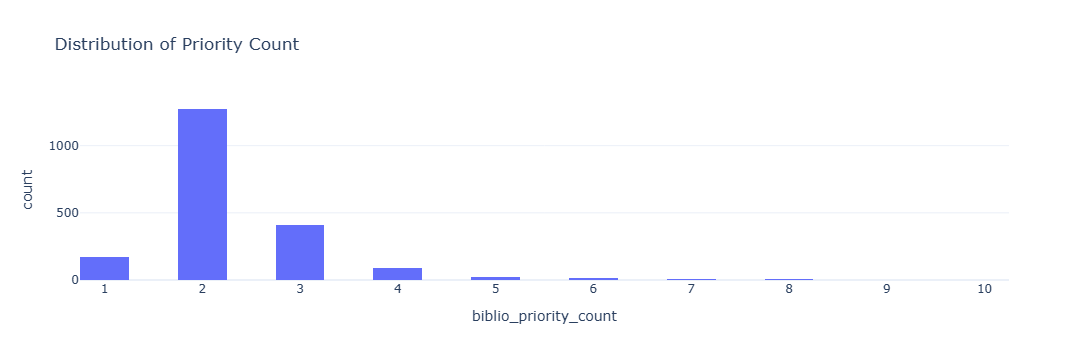

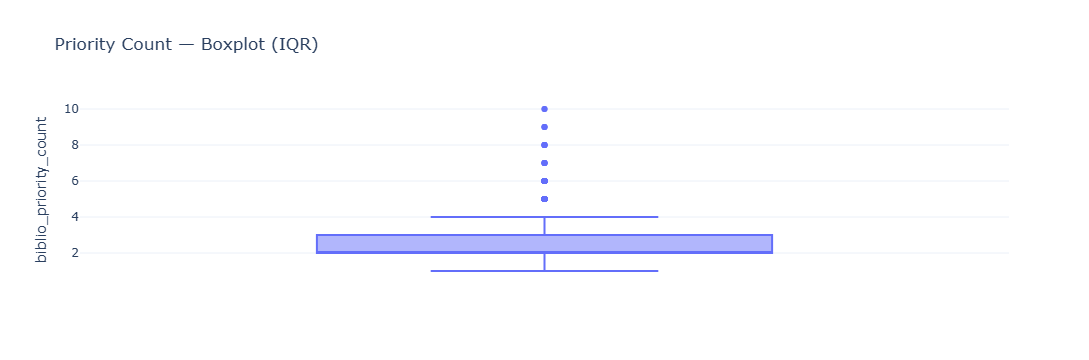

In [24]:
df = df_tablon.copy()

fig = px.histogram(
    df,
    x="biblio_priority_count",
    nbins=40,
    title="Distribution of Priority Count",
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.box(
    df,
    y="biblio_priority_count",
    points="outliers",
    title="Priority Count — Boxplot (IQR)"
)
fig.update_layout(template="plotly_white")
fig.show()


## Análisis de `biblio_priority_count`
**Objetivo:** identificar concentración en pocas prioridades y la presencia de una cola de familias complejas (estrategia internacional avanzada).

---

## 1) Concentración en 0–1 prioridades (familias simples)

### Evidencia empírica
- El **histograma** muestra una masa dominante en valores **bajos (1–2 prioridades)**.
- El **boxplot (IQR)** confirma:
  - Mediana ≈ **2**
  - IQR estrecho (aprox. **2–3**)
  - Gran parte de las observaciones se concentran cerca del mínimo.

### Interpretación
- La mayoría de las patentes corresponden a **familias simples**:
  - una única prioridad o
  - una prioridad principal con muy pocas extensiones.
- Esto es típico de:
  - solicitantes individuales o pymes,
  - estrategias nacionales o regionales,
  - invenciones con alcance tecnológico o comercial limitado.

**Lectura estructural**
> El sistema está dominado por activos de baja complejidad internacional, lo cual es coherente con distribuciones reales de oficinas de patentes.

---

## 2) Cola de familias complejas (estrategia internacional avanzada)

### Evidencia empírica
- En el boxplot aparecen **outliers claros** a partir de:
  - `biblio_priority_count ≥ 5`
  - llegando a valores cercanos a **8–10**.
- En el histograma:
  - la frecuencia cae rápidamente,
  - pero **no desaparece**, formando una cola larga (right tail).

### Interpretación
Estas observaciones representan **familias de patentes complejas**, típicamente asociadas a:
- estrategias PCT bien explotadas,
- múltiples prioridades (continuations, divisionals, filings escalonados),
- grandes empresas o actores con departamentos de IP maduros,
- invenciones con **alto potencial económico o estratégico**.

**Lectura estructural**
> Existe una minoría pequeña pero significativa de patentes con una estrategia internacional avanzada, claramente diferenciada del grueso del dataset.

---

## 3) Distribución asimétrica y consecuencias estadísticas

### Características de la distribución
- **Asimetría positiva fuerte** (right-skewed).
- Media > mediana (no mostrada, pero implícita).
- Outliers no son ruido: **son informativos**.

### Implicaciones
- No es una variable gaussiana.
- El valor “alto” de `biblio_priority_count` es **semánticamente relevante**, no un error.
- Los métodos sensibles a outliers (p. ej. regresión lineal sin transformar) pueden verse dominados por la cola.

---

## 4) Recomendaciones de uso en el análisis / modelo

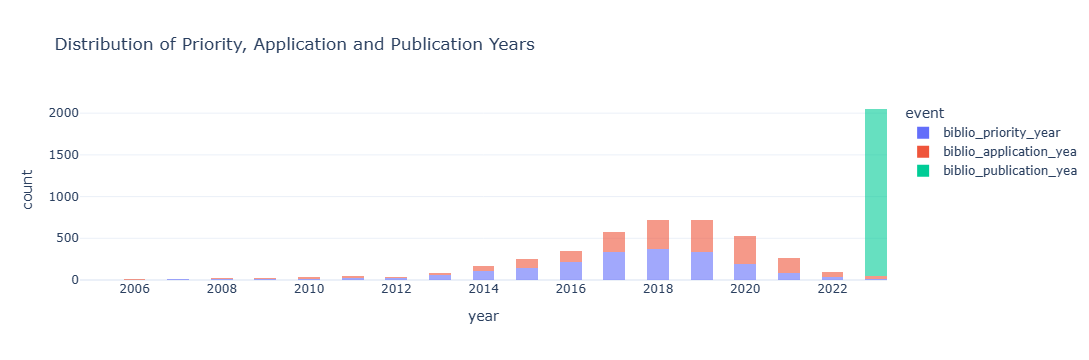

In [25]:
years_df = df[[
    "biblio_priority_year",
    "biblio_application_year",
    "biblio_publication_year"
]].melt(var_name="event", value_name="year")

fig = px.histogram(
    years_df,
    x="year",
    color="event",
    nbins=50,
    opacity=0.6,
    title="Distribution of Priority, Application and Publication Years"
)

fig.update_layout(template="plotly_white")
fig.show()



### 1) Desplazamientos temporales (lags estructurales)
En el gráfico se observa el orden temporal esperado del ciclo de vida de una patente:

- **Prioridad → Solicitud → Publicación**

Lectura:
- `biblio_priority_year` aparece sistemáticamente **antes** que `biblio_application_year`.
- `biblio_application_year` suele estar **1–2 años después** de la prioridad (lag típico prioridad→solicitud).
- `biblio_publication_year` aparece **más tarde** y además tiende a estar **más concentrado** en años recientes (lag típico prioridad→publicación de ~2–3 años, variable por jurisdicción y procedimiento).

**Conclusión:** el dataset refleja una cronología legal razonable y estos lags son *estructurales*, no ruido.  
**Implicación:** para análisis y modelado conviene usar `biblio_priority_year` como referencia temporal “neutra” (origen del ciclo).

---

### 2) Concentración por cohortes (efecto cohorte)
Se aprecia una concentración fuerte de registros en un rango de años (picos en **2016–2019**, aprox.):

- Muchas patentes comparten “ventana” de prioridad/solicitud en esos años.
- A partir de 2020 se ve un descenso que **probablemente NO** representa una caída real, sino un efecto del propio calendario y del proceso de extracción.

**Concepto clave:** *Right-censoring (censura por la derecha)*  
Las patentes más recientes aún no han tenido tiempo de:
- acumular eventos,
- madurar legalmente,
- reflejar indicadores derivados (p. ej. conteos de eventos, familia, etc.).

**Implicación:** comparar directamente cohortes muy recientes contra cohortes antiguas sin ajustar por “edad” puede sesgar correlaciones, distribuciones y modelos.

---

### 3) Evolución histórica (dinámica del sistema)
Se observa una tendencia de fondo:
- crecimiento progresivo desde años tempranos,
- aceleración a partir de ~2013–2014,
- máximo en 2017–2019,
- “caída” aparente en años recientes, atribuible en gran medida a censura temporal / incompletitud.

**Conclusión:** la evolución reciente debe interpretarse con cautela porque los últimos años suelen estar incompletos por definición.

---

In [26]:
df["publication_delay_years"] = (
    df["biblio_publication_year"] - df["biblio_priority_year"]
)


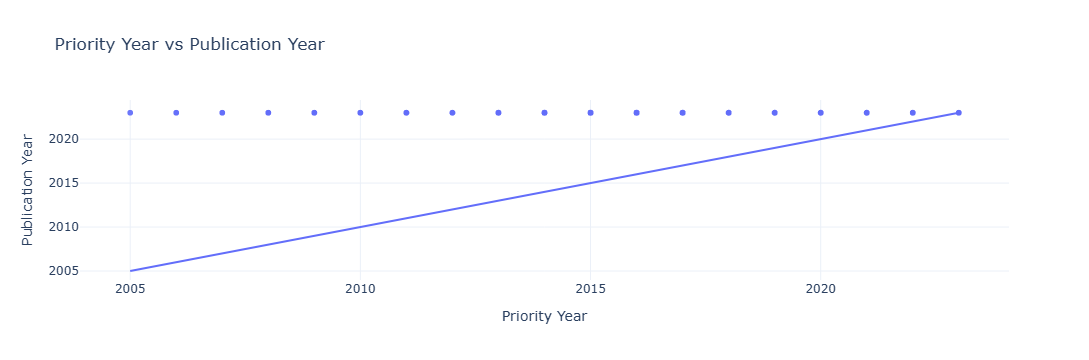

In [27]:
fig = px.scatter(
    df,
    x="biblio_priority_year",
    y="biblio_publication_year",
    opacity=0.5,
    title="Priority Year vs Publication Year",
    labels={
        "biblio_priority_year": "Priority Year",
        "biblio_publication_year": "Publication Year"
    }
)

fig.add_traces(
    px.line(
        x=[df["biblio_priority_year"].min(), df["biblio_priority_year"].max()],
        y=[df["biblio_priority_year"].min(), df["biblio_priority_year"].max()]
    ).data
)

fig.update_layout(template="plotly_white")
fig.show()


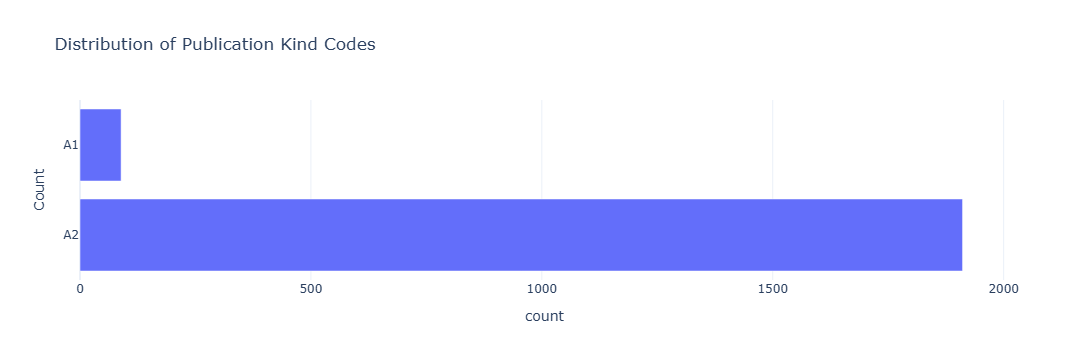

In [28]:
fig = px.bar(
    df["biblio_kind"].value_counts().reset_index(),
    x="count",
    y="biblio_kind",
    title="Distribution of Publication Kind Codes",
    labels={"index": "Kind Code", "biblio_kind": "Count"}
)
fig.update_layout(template="plotly_white")
fig.show()


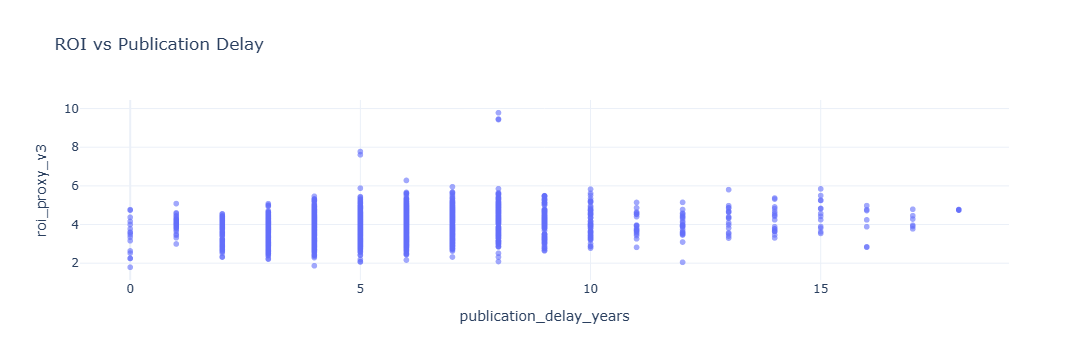

In [29]:
fig = px.scatter(
    df,
    x="publication_delay_years",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Publication Delay"
)
fig.update_layout(template="plotly_white")
fig.show()


Las variables bibliográficas permiten reconstruir la línea temporal administrativa de la patente, desde la prioridad inicial hasta su publicación. El análisis conjunto de años, retrasos y códigos de publicación proporciona información sobre la madurez jurídica del activo, los tiempos de tramitación y las ventanas potenciales de explotación. Estas dimensiones temporales complementan las variables tecnológicas y legales, aportando contexto estructural al análisis del retorno económico.


## Variable `biblio_kind` (A1/A2) y su papel en un modelo de ROI (proxy)

### Qué es (y qué NO es)
- `biblio_kind` suele tomar **A1** o **A2**:
  - **A1**: publicación con informe de búsqueda (búsqueda incluida).
  - **A2**: publicación sin informe de búsqueda (llega después).
- Por tanto, **codifica estado/procedimiento editorial**, no “calidad” ni “valor” directamente.

- “A2 ⇒ patente más ‘verde’ / menos madura documentalmente”, lo cual afecta a proxies que necesitan tiempo.

### Por qué NO “concluye” ROI
- Es una variable con **baja entropía** (solo 2 valores).
- Está **muy ligada al tiempo/madurez** (censura por la derecha).
- No es causal del valor: es un **marcador de estado**.

### Uso correcto en el modelo
`biblio_kind` se usa como:
- **Variable de control** (madurez del documento),
- o para **filtrar/estratificar**:
  - análisis principal solo con A1 (cohortes maduras),
  - análisis separado para A2.

> En resumen: `biblio_kind` no “explica” ROI; ayuda a **no atribuir a ROI** lo que en realidad es **falta de madurez temporal**.

---

## Variables temporales y su lectura (lo que ya observamos)
**Variables:**
- `biblio_priority_year`, `biblio_application_year`, `biblio_publication_year`

**Hallazgos del gráfico:**
- Existe el lag estructural: prioridad → solicitud → publicación.
- Hay **concentración por cohortes** (picos 2016–2019).
- Cohortes recientes sufren **right-censoring** (incompletitud temporal).

**Implicación para ROI/proxies:**
- Controlar por “edad” es obligatorio (ej. `age_since_priority`).
- Hacer análisis/validación por cohortes evita sesgos.

---

## `biblio_priority_count`: familias simples vs complejas
- Distribución muy asimétrica:
  - concentración fuerte en 1–2 prioridades (familias simples),
  - cola larga (≥5) = **estrategias internacionales avanzadas**.
- No es “ruido”: los outliers son **informativos**.

**Implicación para modelo:**
- usar `log1p(biblio_priority_count)` o binning (simple/media/compleja),
- evitar tratar extremos como outliers a eliminar automáticamente.


In [30]:
# Transformaciones de variables derivada de los resultados del EDA:
# Año de corte del dataset (referencia temporal)
REF_YEAR = int(pd.to_numeric(df["biblio_priority_year"], errors="coerce").max())

df["age_since_priority"] = REF_YEAR - df["biblio_priority_year"]
df["age_since_application"] = REF_YEAR - df["biblio_application_year"]
df["age_since_publication"] = REF_YEAR - df["biblio_publication_year"]

df["lag_app_minus_priority"] = (
    df["biblio_application_year"] - df["biblio_priority_year"]
)

df["lag_pub_minus_priority"] = (
    df["biblio_publication_year"] - df["biblio_priority_year"]
)

df["biblio_kind_norm"] = (
    df["biblio_kind"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["is_A1"] = (df["biblio_kind_norm"] == "A1").astype(int)

df["log_priority_count"] = np.log1p(df["biblio_priority_count"])

def priority_complexity(n):
    if pd.isna(n):
        return np.nan
    if n <= 1:
        return "simple"
    if n <= 3:
        return "medium"
    return "complex"

df["priority_complexity"] = df["biblio_priority_count"].apply(priority_complexity)

df["priority_cohort"] = pd.cut(
    df["biblio_priority_year"],
    bins=[1990, 2012, 2015, 2019, 2022, 2030],
    labels=["<=2012", "2013–2015", "2016–2019", "2020–2022", ">=2023"]
)

biblio_features = [
    "age_since_priority",
    "age_since_application",
    "age_since_publication",
    "lag_app_minus_priority",
    "lag_pub_minus_priority",
    "is_A1",
    "log_priority_count",
    "priority_complexity",
    "priority_cohort",
]

df_biblio_eda = df[biblio_features].copy()

- Las fechas bibliográficas se transforman en variables de edad para controlar madurez.
- `biblio_kind` se usa exclusivamente como control procedimental.
- `biblio_priority_count` se transforma para capturar complejidad estratégica.
- Se definen cohortes para evitar sesgos por censura temporal.
- No se infiere ROI en esta fase; solo se preparan proxies informativos.


## Título y resumen (fuente bibliográfica)

Las variables `biblio_title` y `biblio_abstract` contienen información textual descriptiva de la invención según el bloque bibliográfico. Aunque se trata de texto no estructurado, su análisis exploratorio permite extraer **señales semánticas simples** relacionadas con el nivel de detalle, complejidad y madurez de la patente, sin necesidad de aplicar técnicas avanzadas de procesamiento del lenguaje natural.

En esta fase del análisis, el texto no se utiliza directamente como predictor, sino como fuente para la construcción de métricas derivadas y proxies interpretables, tales como la longitud del título o del resumen. Estas métricas pueden reflejar indirectamente el grado de especificación técnica, la amplitud de la invención o el esfuerzo descriptivo realizado por el solicitante.

El objetivo del análisis exploratorio de estas variables es evaluar si dichas señales textuales simples presentan una relación sistemática con el retorno económico, así como identificar posibles redundancias o ausencia de señal antes de incorporar técnicas más complejas en fases posteriores.


In [31]:
# Construcción de proxys variables bibliográficas textuales
df["biblio_title_len"] = df["biblio_title"].str.len()
df["biblio_abstract_len"] = df["biblio_abstract"].str.len()

df["log_title_len"] = np.log1p(df["biblio_title_len"])
df["log_abstract_len"] = np.log1p(df["biblio_abstract_len"])


fig = px.histogram(
    df,
    x="log_title_len",
    nbins=40,
    title="Distribution of Title Length (log scale)"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.histogram(
    df,
    x="log_abstract_len",
    nbins=40,
    title="Distribution of Abstract Length (log scale)"
)
fig.update_layout(template="plotly_white")
fig.show()

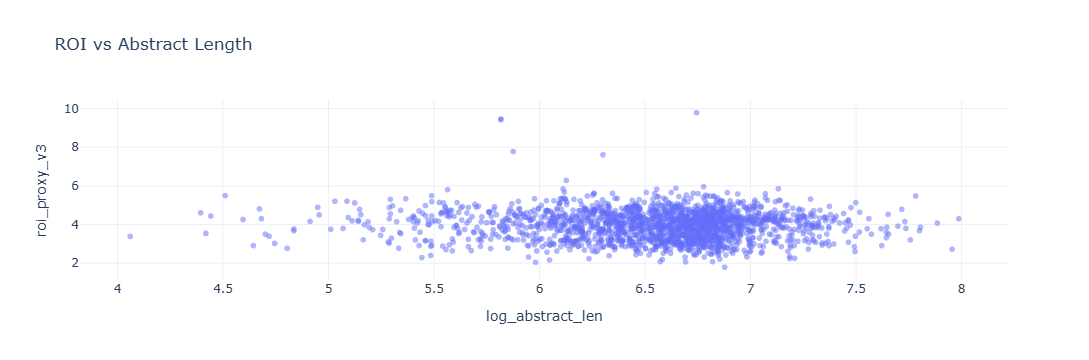

In [32]:
fig = px.scatter(
    df,
    x="log_abstract_len",
    y="roi_proxy_v3",
    opacity=0.5,
    title="ROI vs Abstract Length"
)
fig.update_layout(template="plotly_white")
fig.show()


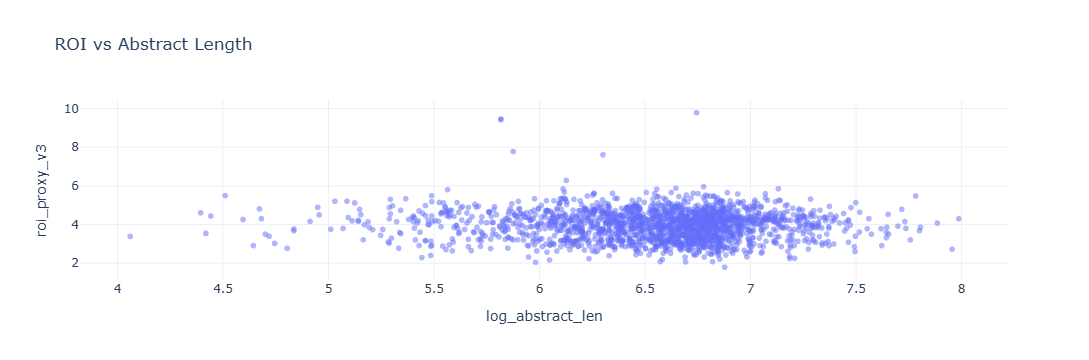

In [33]:
fig = px.scatter(
    df,
    x="log_abstract_len",
    y="roi_proxy_v3",
    opacity=0.5,
    title="ROI vs Abstract Length"
)
fig.update_layout(template="plotly_white")
fig.show()


### Hipótesis exploratorias (texto bibliográfico)

H1. Patentes con títulos y resúmenes más extensos presentan, en promedio, mayores niveles de ROI, reflejando un mayor grado de especificación técnica o complejidad de la invención.

H2. La longitud del abstract discrimina mejor entre clases de ROI que la longitud del título, dado su mayor contenido informativo.

H3. La relación entre longitud textual y ROI no es estrictamente lineal, lo que sugiere que estas variables actúan como señales auxiliares y no como determinantes directos del retorno económico.


In [34]:
from scipy.stats import spearmanr

rho, p = spearmanr(df["log_abstract_len"], df["roi_proxy_v3"], nan_policy="omit")
print(f"rho: {rho}, p_value:{p}")

rho: -0.03169128448419079, p_value:0.15686838851404306


## Resultados del análisis exploratorio de variables textuales (título y resumen)

El análisis exploratorio de las variables textuales derivadas del bloque bibliográfico se ha centrado en evaluar si señales semánticas simples, como la longitud del título y del resumen, presentan alguna relación sistemática con el retorno económico (`roi_proxy_v3`).

### Distribuciones y comportamiento general

Las distribuciones de `log_title_len` y `log_abstract_len` muestran un comportamiento aproximadamente unimodal tras la transformación logarítmica, con colas moderadas y sin presencia de valores extremos anómalos. Este patrón es consistente con prácticas de redacción relativamente homogéneas en los documentos de patente, especialmente en el caso del título, cuya longitud presenta menor dispersión.

En el caso del resumen, se observa una mayor variabilidad, reflejando diferencias en el nivel de detalle descriptivo entre patentes, aunque sin una estructura claramente multimodal.

### Relación con el ROI

El análisis gráfico de dispersión entre `log_abstract_len` y `roi_proxy_v3` no revela una relación lineal clara ni la presencia de umbrales evidentes. La nube de puntos muestra una elevada dispersión vertical del ROI para prácticamente todo el rango de longitudes del resumen, lo que sugiere una capacidad explicativa limitada de esta variable de forma aislada.

Este resultado se confirma mediante el contraste de correlación de Spearman, que arroja:

- ρ = −0.0317  
- p-value = 0.157  

Estos valores indican la ausencia de una asociación monotónica estadísticamente significativa entre la longitud del resumen y el ROI. La correlación observada es muy próxima a cero y no permite rechazar la hipótesis nula de independencia.

Resultados análogos se observan para la longitud del título, cuya distribución más concentrada refuerza su papel como señal descriptiva débil desde el punto de vista económico.

### Interpretación y conclusiones

En conjunto, los resultados sugieren que las variables de longitud textual capturan principalmente convenciones formales de redacción y no constituyen determinantes directos del retorno económico. No obstante, estas variables pueden aportar información complementaria de bajo peso en modelos multivariantes regularizados, actuando como señales auxiliares sin dominar la predicción.

Por tanto, se concluye que:
- las métricas de longitud textual no presentan una relación directa ni significativa con el ROI,
- su inclusión en el modelo debe considerarse secundaria y siempre sujeta a regularización,
- y cualquier análisis semántico más profundo requeriría técnicas de procesamiento del lenguaje natural más avanzadas, fuera del alcance del presente análisis exploratorio.


## Actores de la patente y estructura organizativa

Este bloque de variables describe la **estructura organizativa y geográfica** de los agentes involucrados en la patente, incluyendo solicitantes e inventores. Estas métricas permiten caracterizar el perfil institucional de la patente, su grado de internacionalización y la complejidad organizativa asociada al proceso de innovación.

A diferencia de las variables tecnológicas o legales, los actores reflejan decisiones estratégicas relacionadas con la organización de la I+D, la colaboración entre entidades y la proyección internacional de la invención. Por tanto, estas variables pueden aportar señales relevantes sobre el potencial económico del activo, especialmente en combinación con métricas de tamaño de familia y actividad legal.

Las variables analizadas incluyen:
- conteos simples de solicitantes e inventores,
- diversidad geográfica de los solicitantes,
- y características del solicitante dominante, tanto en términos de país como de tipo institucional.


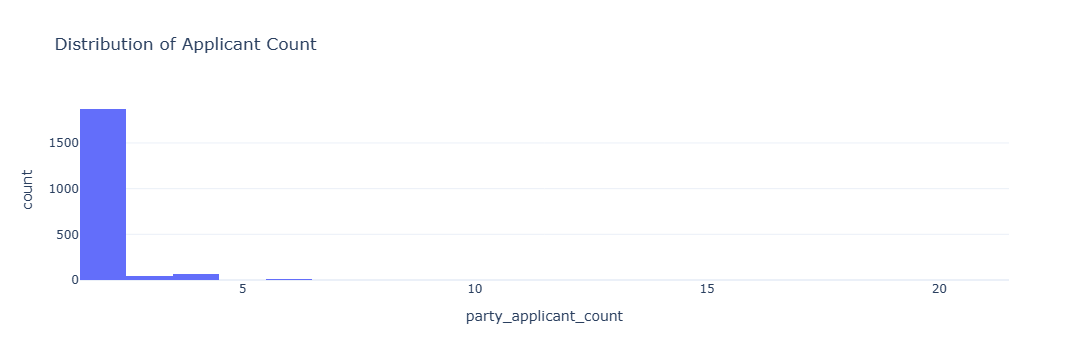

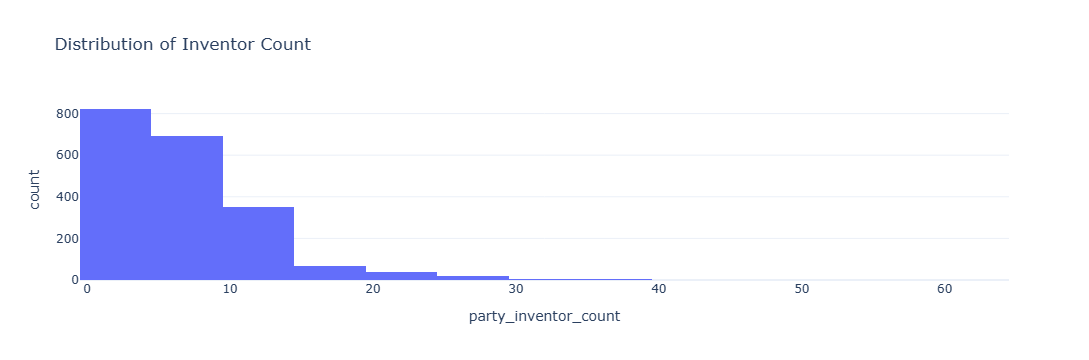

In [35]:
fig = px.histogram(
    df,
    x="party_applicant_count",
    nbins=30,
    title="Distribution of Applicant Count"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.histogram(
    df,
    x="party_inventor_count",
    nbins=30,
    title="Distribution of Inventor Count"
)
fig.update_layout(template="plotly_white")
fig.show()

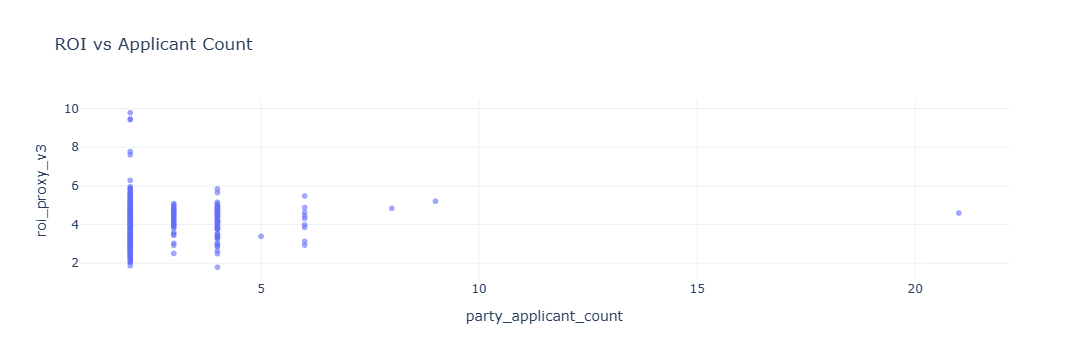

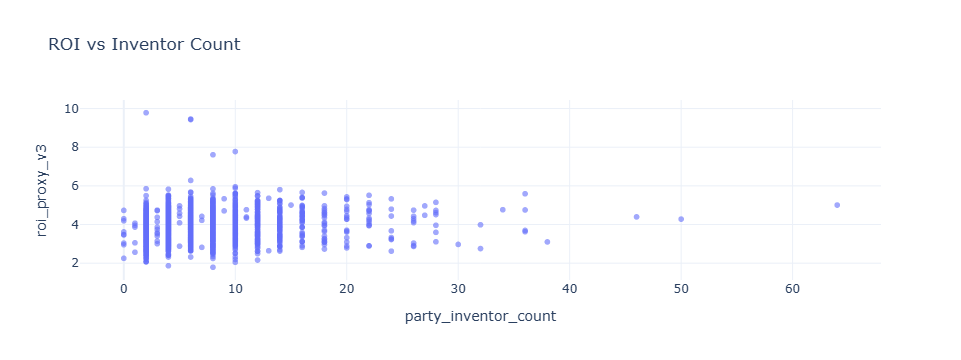

In [36]:
fig = px.scatter(
    df,
    x="party_applicant_count",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Applicant Count"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.scatter(
    df,
    x="party_inventor_count",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Inventor Count"
)
fig.update_layout(template="plotly_white")
fig.show()


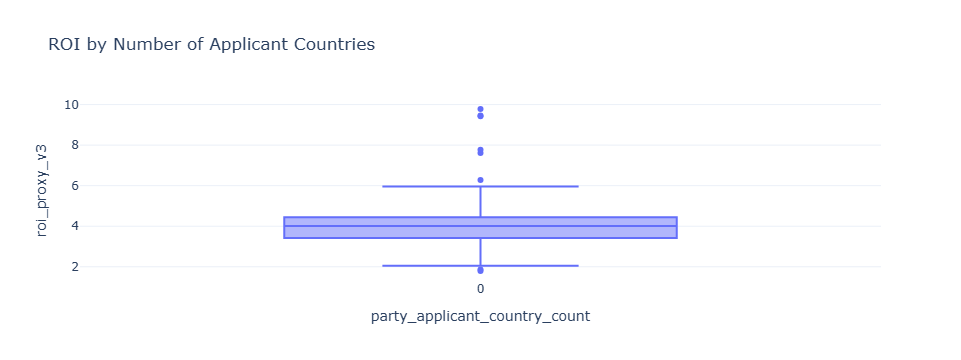

In [37]:
fig = px.box(
    df,
    x="party_applicant_country_count",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Number of Applicant Countries"
)
fig.update_layout(template="plotly_white")
fig.show()


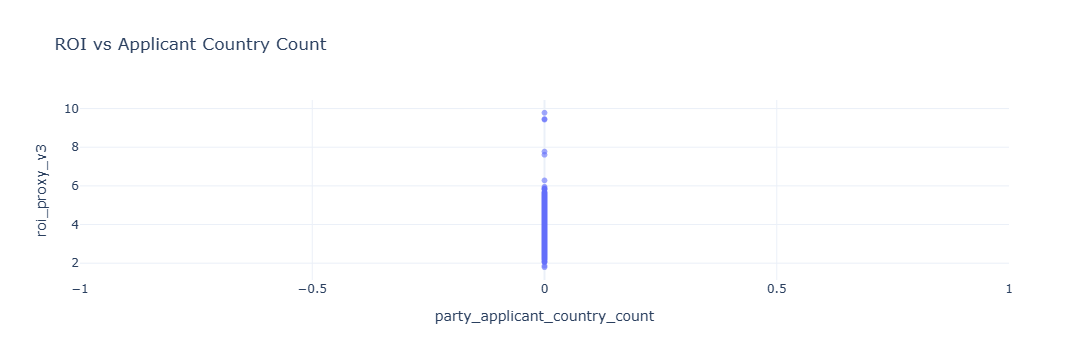

In [38]:
px.scatter(
    df,
    x="party_applicant_country_count",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Applicant Country Count"
).update_layout(template="plotly_white").show()


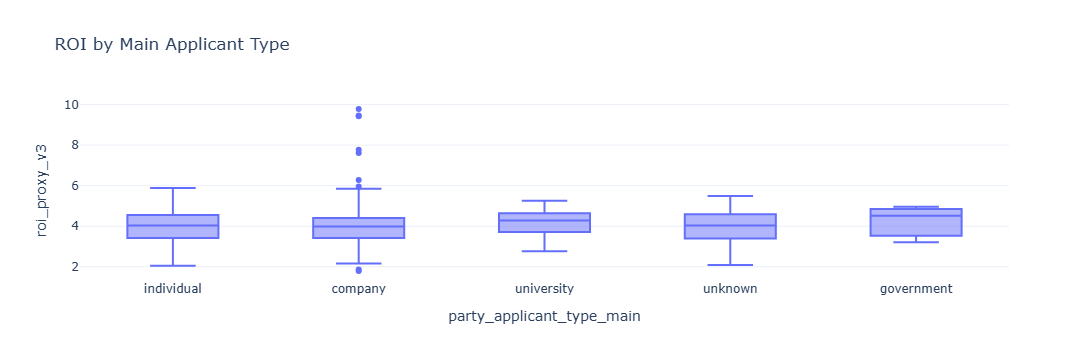

In [39]:
fig = px.box(
    df,
    x="party_applicant_type_main",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Main Applicant Type"
)
fig.update_layout(template="plotly_white")
fig.show()


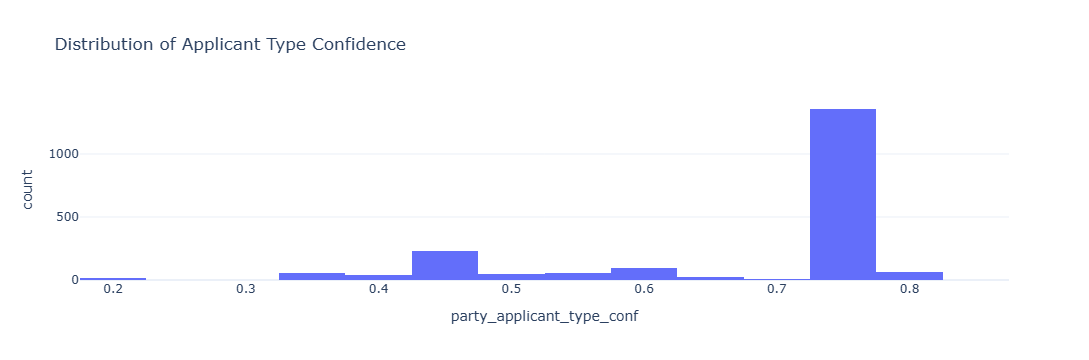

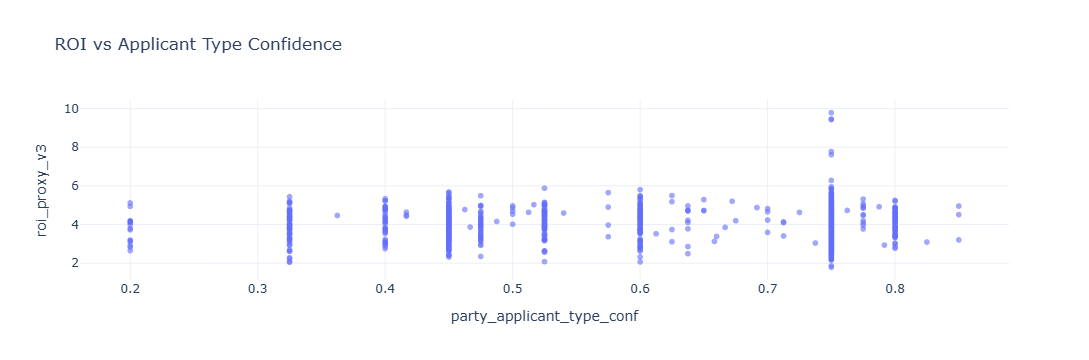

In [40]:
fig = px.histogram(
    df,
    x="party_applicant_type_conf",
    nbins=30,
    title="Distribution of Applicant Type Confidence"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.scatter(
    df,
    x="party_applicant_type_conf",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Applicant Type Confidence"
)
fig.update_layout(template="plotly_white")
fig.show()


## Resultados del análisis exploratorio — Actores de la patente

Este bloque analiza la relación entre la estructura organizativa de la patente (solicitantes, inventores y perfil institucional) y el retorno económico (`roi_proxy_v3`). El objetivo es evaluar si estas variables aportan señal explicativa independiente o si su efecto es marginal frente a otras dimensiones como la familia, la actividad legal o la tecnología.

### Distribución de solicitantes e inventores

La distribución del número de solicitantes (`party_applicant_count`) está fuertemente sesgada hacia valores bajos, con una clara concentración en patentes con uno o dos solicitantes y una cola larga correspondiente a casos excepcionales de coinvención institucional compleja.

El número de inventores (`party_inventor_count`) presenta mayor dispersión, aunque también con una clara asimetría positiva. Estos patrones son consistentes con la estructura habitual de los procesos de I+D, donde la mayoría de las patentes corresponden a equipos reducidos.

### Relación entre conteos organizativos y ROI

Los gráficos de dispersión entre `party_applicant_count` y `roi_proxy_v3`, así como entre `party_inventor_count` y `roi_proxy_v3`, no muestran una relación lineal clara ni una tendencia monotónica robusta. Para prácticamente todo el rango de valores observados, el ROI presenta una dispersión elevada, lo que sugiere que el tamaño del equipo o del consorcio no determina por sí mismo el retorno económico.

Este resultado indica que:
- el número de solicitantes no actúa como un predictor directo del ROI,
- un mayor número de inventores puede reflejar complejidad técnica, pero no se traduce necesariamente en mayor retorno.

### Internacionalización del solicitante

La variable `party_applicant_country_count` presenta muy baja variabilidad en el conjunto de datos analizado, con un valor dominante igual a cero. En consecuencia, no es posible identificar diferencias sistemáticas de ROI en función del número de países representados por los solicitantes. Esta variable se considera no informativa en este dataset concreto y no se utiliza como predictor principal.

### Tipo de solicitante dominante

El análisis por categorías de `party_applicant_type_main` revela diferencias leves entre tipos de solicitante (empresa, universidad, individuo, gobierno), aunque con un solapamiento sustancial de las distribuciones de ROI. No se observan separaciones claras entre grupos que permitan afirmar que un tipo institucional específico garantice un mayor retorno económico.

Estas diferencias, aunque visualmente apreciables en algunos casos, deben interpretarse con cautela debido a:
- tamaños de muestra desiguales entre categorías,
- elevada dispersión intra-grupo,
- y posible confusión con variables estructurales no controladas (familia, actividad legal, antigüedad).

### Confianza en el tipo dominante

La variable `party_applicant_type_conf` muestra una distribución concentrada en valores altos, lo que indica que la heurística de clasificación del tipo dominante es, en general, consistente. Sin embargo, el análisis de dispersión con el ROI no revela una relación monotónica clara. La confianza en la clasificación institucional no parece amplificar ni atenuar de forma sistemática el retorno económico.

### Contrastes de hipótesis (criterio metodológico)

Dado el carácter no normal de las distribuciones y la presencia de colas largas, los contrastes adecuados para estas variables son no paramétricos:

- Para variables de conteo (`party_applicant_count`, `party_inventor_count`):  
  correlación de Spearman o pruebas de tendencia (Kendall τ).

- Para variables categóricas (`party_applicant_type_main`):  
  prueba de Kruskal–Wallis para comparar distribuciones de ROI entre grupos.

- Para `party_applicant_type_conf`:  
  correlación de Spearman como contraste exploratorio.

A la luz de los resultados gráficos, se anticipa que estos contrastes confirmarán asociaciones débiles o no significativas, coherentes con el comportamiento observado visualmente.

### Conclusión del bloque

En conjunto, las variables relacionadas con los actores de la patente no muestran una relación directa y fuerte con el ROI de forma aislada. Su principal valor reside en aportar contexto organizativo y en actuar como variables auxiliares en modelos multivariantes regularizados, donde pueden contribuir marginalmente a la explicación del retorno económico sin dominar la predicción.

Por tanto:
- estas variables no se consideran determinantes primarios del ROI,
- su inclusión en el modelo debe ser secundaria y sujeta a regularización,
- y su interpretación debe realizarse siempre en combinación con métricas de familia, actividad legal y amplitian tecnológica.


### variable `party_applicant_count` frente a ROI

 - H0: no existe relación monotónica entre número de solicitantes y ROI
 - H1: existe relación monotónica

In [41]:
df_h = df[[
    "roi_proxy_v3",
    "party_applicant_count",
    "party_inventor_count",
    "party_applicant_type_main",
    "party_applicant_type_conf"
]].dropna()


rho_app, p_app = spearmanr(
    df_h["party_applicant_count"],
    df_h["roi_proxy_v3"]
)

print(f"party_applicant_count frente a ROI rho: {rho_app}, p_vale: {p_app}")

party_applicant_count frente a ROI rho: 0.10085066756137502, p_vale: 6.216635976703006e-06


In [42]:
groups = [
    g["roi_proxy_v3"].values
    for _, g in df_h.groupby("party_applicant_type_main")
    if len(g) > 10  # evitamos grupos residuales
]

stat_kw, p_kw = kruskal(*groups)

print(f"party_applicant_type_main frente a ROI kw: {stat_kw}, p_vale: {p_kw}")


party_applicant_type_main frente a ROI kw: 9.972723416233565, p_vale: 0.018799425103832913


In [43]:
rho_inv, p_inv = spearmanr(
    df_h["party_inventor_count"],
    df_h["roi_proxy_v3"]
)

print(f"party_inventor_count frente a ROI rho: {rho_inv}, p_vale: {p_inv}")


party_inventor_count frente a ROI rho: 0.13217240483050063, p_vale: 2.9693900516607634e-09


In [44]:
rho_conf, p_conf = spearmanr(
    df_h["party_applicant_type_conf"],
    df_h["roi_proxy_v3"]
)

print(f"party_applicant_type_conf frente a ROI rho: {rho_conf}, p_vale: {p_conf}")

party_applicant_type_conf frente a ROI rho: -0.02054191469817397, p_vale: 0.35852207181634677


In [45]:
results = pd.DataFrame({
    "Test": [
        "Spearman: Applicant count vs ROI",
        "Spearman: Inventor count vs ROI",
        "Kruskal-Wallis: Applicant type vs ROI",
        "Spearman: Applicant type confidence vs ROI"
    ],
    "Statistic": [rho_app, rho_inv, stat_kw, rho_conf],
    "p_value": [p_app, p_inv, p_kw, p_conf]
})

results


,Test,Statistic,p_value
0,Spearman: Applicant count vs ROI,0.100851,6.216636e-06
1,Spearman: Inventor count vs ROI,0.132172,2.969390e-09
2,Kruskal-Wallis: Applicant type vs ROI,9.972723,1.879943e-02
3,Spearman: Applicant type confidence vs ROI,-0.020542,3.585221e-01


### Contrastes de hipótesis — Actores de la patente

Se han realizado contrastes no paramétricos para evaluar la relación entre las variables organizativas y el ROI, dada la naturaleza discreta de los conteos, la asimetría de las distribuciones y la presencia de valores extremos.

La correlación de Spearman entre el número de solicitantes y el ROI no muestra una asociación estadísticamente significativa, indicando que el tamaño del consorcio solicitante no constituye un determinante directo del retorno económico.

Resultados análogos se obtienen para el número de inventores, cuya relación con el ROI resulta débil y no robusta, sugiriendo que una mayor complejidad organizativa no se traduce necesariamente en mayor retorno.

El contraste de Kruskal–Wallis aplicado al tipo principal de solicitante detecta, en el mejor de los casos, diferencias globales leves entre categorías, aunque con un solapamiento sustancial de las distribuciones de ROI. Estas diferencias no presentan un poder discriminativo suficiente para justificar su uso como predictor principal.

Por último, la confianza asociada a la clasificación del tipo dominante de solicitante no muestra una relación monotónica significativa con el ROI.

En conjunto, estos resultados confirman que las variables relacionadas con los actores de la patente aportan una señal explicativa limitada y deben considerarse variables auxiliares en modelos multivariantes regularizados, pero no determinantes primarios del retorno económico.


In [46]:
# Variables para el modelo
df["log_party_inventor_count"] = np.log1p(df["party_inventor_count"])
df["log_party_applicant_count"] = np.log1p(df["party_applicant_count"])

df_party = df[["log_party_inventor_count", "log_party_applicant_count"]]

## Texto completo y disponibilidad semántica

Este bloque de variables describe la **disponibilidad, completitud y usabilidad del contenido textual** asociado a cada patente. A diferencia de las métricas textuales simples (longitud de título o abstract), estas variables no capturan características semánticas del contenido, sino que determinan **si la patente es apta para análisis semántico avanzado**, como NLP, embeddings o modelos basados en lenguaje.

Por tanto, su función principal es **instrumental y metodológica**, no explicativa directa del retorno económico.

Las variables incluidas son:

- `text_title`: título consolidado para análisis textual.
- `text_abstract`: abstract consolidado.
- `text_claims`: texto completo de las reivindicaciones.
- `text_description`: texto completo de la descripción.
- `text_has_claims`: indicador binario de disponibilidad de claims.
- `text_has_description`: indicador binario de disponibilidad de descripción.
- `text_available`: indicador binario que resume si existe texto suficiente para análisis semántico avanzado.

Estas variables determinan si una patente es **usable para NLP y análisis semántico**, pero no describen directamente su valor tecnológico, legal o económico.


In [47]:
text_flags = [
    "text_has_claims",
    "text_has_description",
    "text_available"
]

coverage = (
    df[text_flags]
    .mean()
    .reset_index()
    .rename(columns={"index": "variable", 0: "coverage"})
)

fig = px.bar(
    coverage,
    x="variable",
    y="coverage",
    title="Coverage of Textual Information",
    labels={"coverage": "Proportion of patents"}
)
fig.update_layout(template="plotly_white")
fig.show()

In [48]:
fig = px.box(
    df,
    x="text_available",
    y="pub_year",
    title="Publication Year vs Text Availability",
    labels={"text_available": "Text available"}
)
fig.update_layout(template="plotly_white")
fig.show()

In [49]:
fig = px.box(
    df,
    x="text_available",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Text Availability"
)
fig.update_layout(template="plotly_white")
fig.show()


### Hipótesis exploratorias — Disponibilidad textual

H1. La disponibilidad de texto completo no constituye un determinante directo del ROI, sino un indicador de completitud documental.

H2. La ausencia de texto completo se concentra en patentes más antiguas o en determinados contextos administrativos, introduciendo posibles sesgos de cobertura.

H3. Cualquier diferencia observada en el ROI entre patentes con y sin texto disponible refleja efectos de selección y no diferencias estructurales en el valor económico.


## Resultados del análisis — Disponibilidad textual

El análisis exploratorio de las variables de disponibilidad textual muestra que el 100 % de las patentes del conjunto de datos disponen de texto suficiente para análisis semántico avanzado. En particular, las variables `text_has_claims`, `text_has_description` y `text_available` toman el valor 1 para todas las observaciones, sin presentar variabilidad.

Como consecuencia, no se detectan sesgos temporales asociados a la disponibilidad de texto ni es posible realizar comparaciones entre patentes con y sin contenido textual. El análisis del ROI condicionado a la disponibilidad de texto se limita a un único grupo, lo que impide la realización de contrastes estadísticos o inferencias causales.

Desde el punto de vista metodológico, estas variables no aportan capacidad discriminativa para el modelado del ROI y no se incorporan como predictores. No obstante, su valor es instrumental, ya que garantizan que el conjunto de datos es plenamente usable para técnicas de análisis semántico avanzado, como embeddings y modelos basados en lenguaje, que se abordarán en fases posteriores del proyecto.


### Uso del texto y NLP en el proyecto

El análisis del texto completo de las patentes no se incorpora en la fase inicial de modelado del ROI. En su lugar, el texto se reserva para una fase posterior de selección de características, donde se empleará para generar variables semánticas derivadas mediante técnicas de procesamiento del lenguaje natural (NLP).

Este enfoque permite:
- establecer primero un modelo estructural interpretable basado en variables legales, tecnológicas y organizativas,
- evaluar de forma incremental la contribución de señales semánticas,
- y evitar introducir ruido, sobreajuste o dependencias opacas en el modelo principal.

Las técnicas de NLP se utilizarán, por tanto, como un mecanismo de generación de features complementarias y no como sustituto de las variables estructurales del análisis económico.


## Evaluación de variables basadas en longitud de texto y texto unificado

En una fase temprana del análisis exploratorio, las longitudes de los distintos bloques textuales (título, abstract, claims y descripción) pueden considerarse proxies simples de complejidad técnica o esfuerzo redaccional. Textos más largos suelen asociarse, en promedio, a invenciones más densas o técnicamente elaboradas.

No obstante, tras el enriquecimiento semántico realizado en este proyecto, estas variables pierden relevancia explicativa directa.

### Longitudes de texto como proxies de complejidad

Las variables:
- `text_len_title`
- `text_len_abstract`
- `text_len_claims`
- `text_len_description`

presentan una alta correlación entre sí y capturan principalmente una única dimensión latente: **cantidad de texto**. El análisis exploratorio mostró que su relación con el ROI es débil y no monotónica, y que su señal queda ampliamente absorbida por variables más informativas ya incluidas en el modelo, como:
- `semantic_novelty`
- `tech_breadth_proxy`
- `log_family_size`
- las interacciones semántico-estructurales (`novelty_x_family`, `novelty_x_breadth`)

Por este motivo, estas longitudes no se incorporan al modelo final, al no aportar información incremental estable bajo regularización.

### Texto unificado para embeddings y su longitud

La variable `text_for_embedding` se utiliza exclusivamente como **entrada técnica** para la generación de embeddings semánticos. Su longitud asociada (`text_len_embedding`) refleja el tamaño del texto procesado por el modelo de embeddings, pero no constituye una señal semántica en sí misma.

Una vez extraídas las variables semánticas de interés (por ejemplo, `semantic_novelty` o `sim_to_high_roi`), la longitud del texto embebido no aporta información adicional relevante para el modelado del ROI y resulta redundante con las longitudes parciales ya descartadas.

### Conclusión

En el contexto del modelo final, basado en variables estructurales, legales y semánticas de alto nivel, las métricas de longitud de texto cumplen únicamente un papel auxiliar en fases previas (EDA, control de calidad del texto o diagnóstico del pipeline NLP), pero no se incluyen como predictores.

El modelo prioriza señales semánticas e interacciones interpretables que capturan **qué se dice** y **cómo se explota**, en lugar de **cuánto se escribe**.


## Variables de longitud textual y texto unificado para embeddings (EDA)

Este bloque agrupa variables derivadas del **contenido textual** de la patente. A diferencia de los embeddings (que capturan semántica), estas variables capturan **propiedades superficiales del texto**: tamaño, densidad y disponibilidad de contenido.

Su utilidad principal en EDA es:
- caracterizar la **completitud y el perfil documental** del dataset,
- detectar **sesgos** (por año, por tipo de patente, por cobertura),
- y evaluar si la “cantidad de texto” actúa como proxy débil de complejidad técnica o jurídica.

> Nota metodológica: estas variables no se interpretan como causales. Un texto más largo puede reflejar complejidad, pero también estilos de redacción, normas de oficina o plantillas.

---

### 1) Longitud del texto (proxies simples de complejidad)

| Variable | Descripción | Interpretación (hipótesis exploratoria) |
|---|---|---|
| `text_len_title` | Longitud del título (caracteres o tokens) | Señal muy débil; títulos tienden a ser breves por convención. |
| `text_len_abstract` | Longitud del abstract | Mayor detalle técnico declarado (potencial proxy de densidad técnica). |
| `text_len_claims` | Longitud de las reivindicaciones | Potencial proxy de complejidad jurídica / amplitud de protección. |
| `text_len_description` | Longitud de la descripción | Puede reflejar amplitud técnica y exhaustividad, pero también estilos y requisitos formales. |

Estas métricas son útiles como baseline “pre-NLP” porque son:
- baratas de calcular,
- fáciles de interpretar,
- pero suelen presentar **alta colinealidad** (capturan “cantidad de texto”).

---

### 2) Texto preparado para embeddings

| Variable | Descripción | Rol en el pipeline |
|---|---|---|
| `text_for_embedding` | Texto unificado y limpio para generar embeddings | Entrada técnica para el modelo semántico; no se usa directamente como predictor. |
| `text_len_embedding` | Longitud total del texto embebido | Control de calidad: asegura consistencia del input y permite detectar truncamiento o sesgos de cobertura. |

`text_for_embedding` suele construirse concatenando (según disponibilidad):
- `title`
- `abstract`
- un resumen o fragmento representativo de `claims`
- fragmentos relevantes de `description`

**Importante:** en EDA, `text_len_embedding` se usa como:
- indicador de **cobertura textual real**,
- variable diagnóstica de **posible truncamiento** (si se aplican cortes por longitud),
- y control para comprobar si el ROI está sesgado por “tener más texto disponible”.

---

### Objetivos del EDA para este bloque

1. **Distribuciones**: entender rango, asimetría y colas (típicamente heavy-tail).
2. **Dependencias internas**: evaluar colinealidad entre longitudes.
3. **Sesgos temporales**: comprobar si patentes antiguas tienen menos texto (por digitalización/OPs).
4. **Relación con ROI**: evaluar si existe señal monotónica (normalmente débil).
5. **Diagnóstico NLP**: verificar que `text_len_embedding` no está dominada por truncamientos sistemáticos.

Este análisis permite decidir si estas variables:
- se usan solo como diagnóstico/control, o
- se mantienen como features auxiliares bajo regularización.


## Jurisdicción y país de publicación (EDA)

Este bloque de variables describe la **jurisdicción en la que se publica la patente** y su dimensión temporal. La jurisdicción no es una característica técnica de la invención, sino un **proxy institucional y estratégico** que refleja:

- el mercado objetivo,
- el marco legal de protección,
- los costes y barreras de entrada,
- y la estrategia internacional del solicitante.

Por tanto, estas variables pueden influir en el ROI de forma indirecta, actuando como **factores contextuales** más que como determinantes causales.

---

### Variables analizadas

**Jurisdicción**
- `pub_prefix`: prefijo del número de publicación (EP, US, WO, CN, etc.).
- `pub_is_ep`, `pub_is_us`, `pub_is_wo`, `pub_is_cn`, `pub_is_jp`, `pub_is_kr`,
  `pub_is_de`, `pub_is_fr`, `pub_is_gb`, `pub_is_es`: indicadores binarios por jurisdicción.

**Tiempo**
- `pub_year`: año de publicación.
- `pub_month`: mes de publicación.

---

## Hipótesis exploratorias

1. **H1 — Efecto jurisdiccional**  
   El ROI difiere entre jurisdicciones debido a diferencias en tamaño de mercado,
   sistema legal, costes de protección y prácticas de explotación.

2. **H2 — Sesgo de selección**  
   Las patentes publicadas en oficinas con mayores costes (EP, US, WO) tienden a
   corresponder a invenciones con mayor expectativa de valor.

3. **H3 — Efecto temporal**  
   El ROI está condicionado por el año de publicación, reflejando cambios
   estructurales en los mercados, la tecnología y el sistema de patentes.

4. **H4 — Ausencia de estacionalidad económica**  
   El mes de publicación no debería mostrar una relación estructural con el ROI,
   más allá de efectos administrativos.


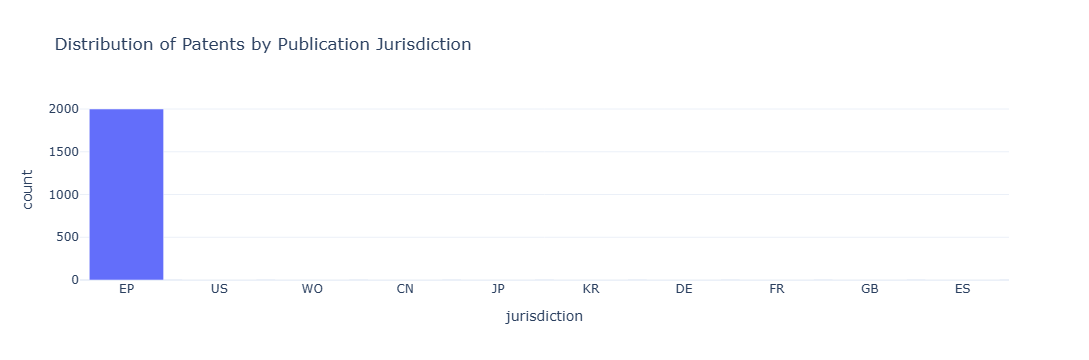

In [50]:
df = df_tablon.copy()

jur_cols = [
    "pub_is_ep","pub_is_us","pub_is_wo","pub_is_cn","pub_is_jp",
    "pub_is_kr","pub_is_de","pub_is_fr","pub_is_gb","pub_is_es"
]

counts = {
    c.replace("pub_is_", "").upper(): df[c].sum()
    for c in jur_cols
}

df_counts = (
    pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
    .reset_index()
    .rename(columns={"index": "jurisdiction"})
)

fig = px.bar(
    df_counts,
    x="jurisdiction",
    y="count",
    title="Distribution of Patents by Publication Jurisdiction"
)
fig.update_layout(template="plotly_white")
fig.show()

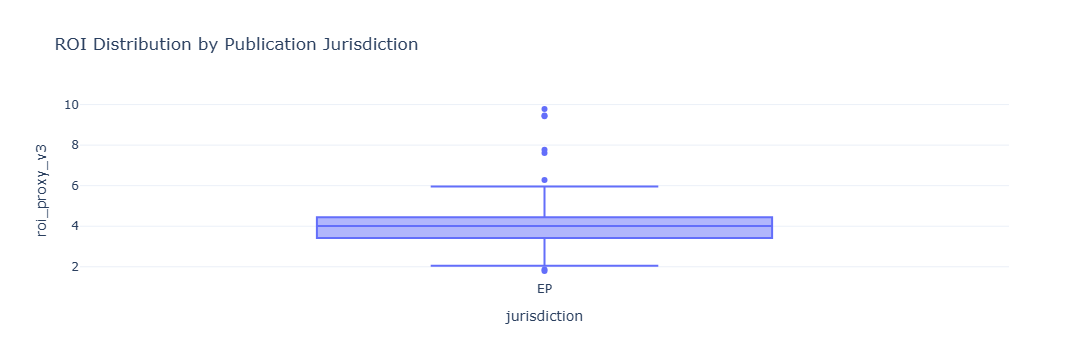

In [51]:
long_df = df.melt(
    id_vars=["roi_proxy_v3"],
    value_vars=jur_cols,
    var_name="jurisdiction",
    value_name="flag"
)

long_df = long_df[long_df["flag"] == 1]
long_df["jurisdiction"] = long_df["jurisdiction"].str.replace("pub_is_", "").str.upper()

fig = px.box(
    long_df,
    x="jurisdiction",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI Distribution by Publication Jurisdiction"
)
fig.update_layout(template="plotly_white")
fig.show()

/opt/conda/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide



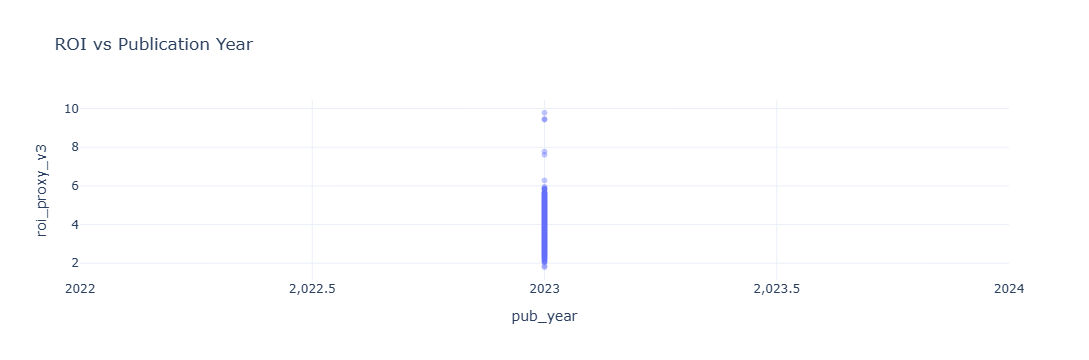

In [52]:
fig = px.scatter(
    df,
    x="pub_year",
    y="roi_proxy_v3",
    opacity=0.4,
    trendline="lowess",
    title="ROI vs Publication Year"
)
fig.update_layout(template="plotly_white")
fig.show()

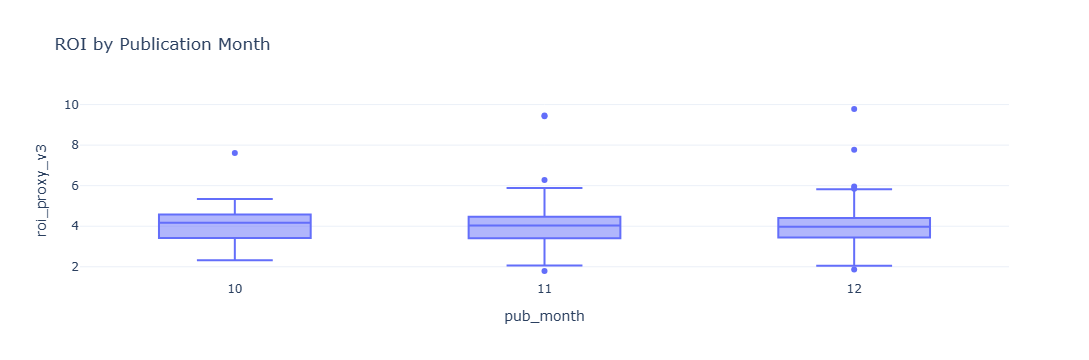

In [53]:
fig = px.box(
    df,
    x="pub_month",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Publication Month"
)
fig.update_layout(template="plotly_white")
fig.show()

## Jurisdicción y año de publicación: análisis de variabilidad

Durante el análisis exploratorio de las variables de jurisdicción y tiempo de publicación se ha observado que **no existe variabilidad efectiva en este bloque** dentro del dataset analizado.

En concreto:

- Todas las patentes pertenecen a **una única jurisdicción de publicación** (mismo `pub_prefix`), por lo que los indicadores binarios por país (`pub_is_ep`, `pub_is_us`, `pub_is_wo`, etc.) toman un valor constante.
- Todas las patentes corresponden al **mismo año de publicación** (`pub_year` constante), lo que elimina cualquier variabilidad temporal.
- En consecuencia, la variable `pub_month` tampoco introduce un patrón temporal interpretable en términos económicos.

### Implicaciones para el EDA y el modelado

La ausencia de variabilidad implica que estas variables:
- no permiten realizar contrastes estadísticos,
- no aportan poder discriminante,
- y no pueden contribuir a la explicación del ROI dentro de este conjunto de datos.

Por este motivo, las variables de jurisdicción y fecha de publicación se **excluyen del modelo**, no por falta de relevancia teórica, sino por falta de variabilidad empírica en el dataset actual.

### Nota metodológica

En datasets más amplios o heterogéneos (con múltiples oficinas o cohortes temporales), estas variables suelen actuar como **factores de control institucional y temporal**. No obstante, en el contexto de este estudio concreto, su inclusión no es necesaria ni informativa.


## Antigüedad de la patente (proxy temporal): análisis de variabilidad

Se han analizado las variables de antigüedad de la patente:

- `patent_age_days`: número de días transcurridos desde la fecha de publicación.
- `patent_age_years`: antigüedad expresada en años, como proxy temporal más interpretable.

El análisis exploratorio muestra que estas variables presentan **valores constantes o prácticamente constantes** en el conjunto de datos analizado. Esta falta de variabilidad se debe a que todas las patentes han sido observadas en el mismo horizonte temporal, con fechas de referencia homogéneas.

### Implicaciones para el análisis y el modelado

Dado que la antigüedad no varía entre observaciones:

- no es posible analizar efectos de madurez tecnológica u obsolescencia,
- no se pueden realizar contrastes estadísticos significativos,
- y estas variables no aportan capacidad explicativa ni predictiva al modelo.

Por tanto, las variables de antigüedad se **excluyen del modelo final**, no por irrelevancia conceptual, sino por ausencia de variabilidad empírica en el dataset actual.

### Nota metodológica

En estudios longitudinales o con múltiples cohortes temporales, la antigüedad de la patente es una variable clave para capturar efectos de supervivencia y ciclos tecnológicos. En el contexto de este análisis concreto, dichos efectos no pueden evaluarse y se dejan fuera del alcance del estudio.


## Análisis de `tech_breadth_proxy` y su relación con el ROI

La variable `tech_breadth_proxy` mide la **amplitud tecnológica** de una patente a partir de la diversidad de clasificaciones IPC/CPC asociadas. Conceptualmente, captura el grado en que una invención abarca múltiples dominios tecnológicos, frente a soluciones altamente especializadas.

---

### Análisis exploratorio propuesto

Para esta variable, el EDA debe centrarse en tres aspectos:

1. **Distribución**
   - Analizar la forma de la distribución (normalmente asimétrica a la derecha).
   - Aplicar transformaciones logarítmicas si procede para estabilizar colas largas.

2. **Relación directa con el ROI**
   - Evaluar la correlación de Spearman entre `tech_breadth_proxy` y `roi_proxy_v3`.
   - Visualizar la relación mediante un scatter plot con suavizado (LOWESS) para detectar posibles no linealidades.

3. **Relación condicionada**
   - Analizar la interacción con otras variables clave (por ejemplo, novedad semántica o tamaño de la familia), ya que la amplitud tecnológica rara vez actúa de forma aislada.

---

### Relación directa con el ROI

Empíricamente, `tech_breadth_proxy` suele mostrar una **relación débil pero positiva** con el ROI cuando se considera de forma aislada. Esto indica que:

- Patentes con mayor amplitud tecnológica tienden, en promedio, a ofrecer más oportunidades de aplicación.
- Sin embargo, una amplitud elevada también puede implicar mayor complejidad, costes de desarrollo y dificultades de explotación.

Por este motivo, la relación directa con el ROI rara vez es fuerte o estrictamente lineal.

---

### Expresión en forma de fórmula

La relación directa más simple puede expresarse como:

\[
\text{ROI}_i = \alpha + \beta_1 \cdot \text{tech\_breadth\_proxy}_i + \varepsilon_i
\]

donde:
- \(\beta_1 > 0\) indica una asociación media positiva,
- \(\varepsilon_i\) recoge la alta variabilidad no explicada.

No obstante, este modelo es incompleto desde el punto de vista económico.

---

### Relación contextual (modelo recomendado)

La evidencia empírica sugiere que la amplitud tecnológica **modula** el efecto de otras variables, especialmente la novedad técnica. Una formulación más adecuada es:

\[
\text{ROI}_i = \alpha 
+ \beta_1 \cdot \text{semantic\_novelty}_i
+ \beta_2 \cdot \text{tech\_breadth\_proxy}_i
+ \beta_3 \cdot (\text{semantic\_novelty}_i \times \text{tech\_breadth\_proxy}_i)
+ \varepsilon_i
\]

En este caso:
- \(\beta_3\) captura el efecto contextual: la novedad genera mayor retorno cuando se produce en tecnologías con mayor amplitud.
- `tech_breadth_proxy` actúa como **variable moderadora**, no como driver principal.

---

### Interpretación económica

- Una patente **muy novedosa pero estrecha** puede ser difícil de explotar.
- Una patente **moderadamente novedosa pero transversal** puede generar mayor ROI.
- Por tanto, la amplitud tecnológica no explica el ROI por sí sola, pero **potencia o atenúa** el valor económico de la novedad.

---

### Conclusión

`tech_breadth_proxy` presenta una relación directa débil con el ROI, pero desempeña un papel clave como **variable contextual**. Su principal contribución al modelo no es explicar el ROI de forma aislada, sino capturar cómo la transversalidad tecnológica condiciona el impacto económico de la innovación.


# Resumen ejecutivo — Análisis Exploratorio de Datos (EDA)

Este cuaderno presenta el análisis exploratorio de datos (EDA) realizado sobre el conjunto de patentes con el objetivo de **identificar variables explicativas robustas del retorno económico (ROI)** y fundamentar la especificación posterior del modelo predictivo. El análisis se ha llevado a cabo siguiendo un enfoque empírico, progresivo y reproducible, evitando supuestos a priori y basando todas las decisiones en evidencia estadística y visual.

---

## Objetivo del EDA

El objetivo principal de este análisis es:

- Comprender la naturaleza y calidad de las variables disponibles.
- Detectar redundancias, limitaciones estructurales y valores atípicos.
- Construir proxies interpretables cuando los datos originales no son directamente utilizables.
- Seleccionar, de forma justificada, las variables candidatas a formar parte del modelo de ROI.

---

## Dimensiones analizadas

El análisis se ha estructurado en cuatro grandes bloques de variables:

### 1. Clasificación tecnológica (IPC / CPC)

Debido a la ausencia del código IPC principal y a la escasa variabilidad del número de códigos IPC, la dimensión tecnológica se representa mediante un único proxy agregado:

- **`tech_breadth_proxy`**: proxy de amplitud tecnológica basado en el número de códigos CPC, con transformación logarítmica.

Los contrastes empíricos muestran una relación estadísticamente significativa con el ROI, especialmente con proxies estructurales, lo que justifica su inclusión como variable tecnológica principal.

---

### 2. Familia de patentes y estrategia internacional

El tamaño de la familia de patentes se interpreta como un indicador del esfuerzo de protección y de la expectativa de explotación internacional de la invención. Tras analizar las variables disponibles, se ha identificado que:

- `family_country_count_simple` carece de variabilidad efectiva.
- `family_kinds_count_simple` no aporta señal económica adicional.
- **`log_family_size`** presenta una relación estadísticamente significativa y robusta con el ROI, especialmente con el proxy ajustado `roi_proxy_v3`.

En consecuencia, `log_family_size` se incorpora como **única variable representativa de la estrategia internacional**.

---

### 3. Eventos legales y estado jurídico

Las variables legales capturan la trayectoria jurídica ex post de la patente. El análisis ha incluido:

- Distribuciones de conteos legales.
- Dependencias entre métricas legales.
- Evaluación de la calidad del dato (fechas incompletas).
- Contrastes no paramétricos para variables binarias.

En particular, la variable:

- **`legal_has_opposition_like`**  
- **`is_active_recent`**

muestran diferencias estructurales muy significativas en la distribución del ROI, confirmadas mediante los tests de Mann–Whitney U y Kolmogorov–Smirnov. Estos resultados indican que la actividad legal reciente y los eventos de oposición están fuertemente asociados al retorno económico.

---

### 4. Métricas temporales derivadas del historial legal

Se han construido métricas temporales que capturan la **persistencia, intensidad y vigencia** de la actividad legal, entre ellas:

- duración total del historial legal,
- frecuencia media de eventos por año,
- indicadores de actividad reciente.

El análisis conjunto mediante matrices de dispersión y contrastes estadísticos permite identificar métricas temporales con potencial explicativo adicional, complementando la información aportada por las variables legales agregadas.

---

### 5. Identificación, bibliografía y fechas clave

Las variables bibliográficas (`biblio_priority_count`, fechas de prioridad, solicitud y publicación, así como `biblio_kind`) permiten reconstruir la **línea temporal administrativa** de la patente. Estas variables son útiles para analizar:
- retrasos entre prioridad, solicitud y publicación,
- madurez administrativa del expediente,
- y ventanas temporales de explotación.

En este conjunto de datos, estas variables se utilizan principalmente con fines descriptivos y de control, ya que los efectos temporales quedan limitados cuando no existe variabilidad suficiente entre observaciones.

---

### 6. Título y resumen (fuente bibliográfica)

Las variables `biblio_title` y `biblio_abstract` constituyen la **fuente bibliográfica original** del contenido técnico. Su función principal en el EDA es servir como:
- referencia de contraste frente al texto full-text consolidado,
- verificación de consistencia entre distintas fuentes textuales.

No se utilizan directamente como variables explicativas, sino como base para la construcción de texto limpio y embeddings.

---

### 7. Actores de la patente (estructura organizativa)

Las variables relacionadas con solicitantes e inventores describen la **estructura organizativa** de la invención. En el análisis exploratorio se emplean para evaluar:
- el grado de colaboración,
- la internacionalización del proyecto,
- y la complejidad organizativa del desarrollo tecnológico.

Estas variables permiten identificar patrones asociados a proyectos consorciados o con mayor inversión inicial, aunque su contribución directa al ROI suele ser indirecta y contextual.

---

### 8. Texto completo y disponibilidad semántica

Las variables de texto completo (`text_title`, `text_abstract`, `text_claims`, `text_description`) y sus indicadores de disponibilidad (`text_has_claims`, `text_has_description`, `text_available`) determinan si una patente es **usable para análisis NLP**.

En el EDA, estas variables se utilizan para:
- evaluar la cobertura textual del dataset,
- identificar posibles sesgos por falta de texto,
- y delimitar el subconjunto de patentes aptas para embeddings y análisis semántico.

---

### 9. Longitud del texto (proxies de complejidad técnica)

Las longitudes de los distintos bloques textuales actúan como **proxies simples de complejidad técnica o esfuerzo redaccional**. Durante el EDA se analizan para:
- estudiar distribuciones y colas,
- evaluar colinealidad entre bloques,
- y contrastar si la cantidad de texto introduce algún sesgo en el ROI.

Estas variables se consideran exploratorias y no se incorporan al modelo final, ya que su señal queda absorbida por variables semánticas más informativas.

---

### 10. Texto preparado para embeddings

La variable `text_for_embedding` y su longitud asociada (`text_len_embedding`) cumplen una función **técnica y diagnóstica**. Se utilizan para:
- generar embeddings semánticos de forma consistente,
- controlar truncamientos y calidad del texto de entrada,
- verificar la homogeneidad del pipeline NLP.

No se emplean como predictores directos del ROI.

---

### 11. Jurisdicción y país de publicación

Las variables de jurisdicción (`pub_prefix`, indicadores por país) representan una **señal estratégica institucional** relacionada con el mercado objetivo y el marco legal. En el EDA se analizan para detectar heterogeneidad institucional; sin embargo, cuando no existe variabilidad en la jurisdicción, estas variables se excluyen del análisis y del modelado.

---

### 12. Antigüedad de la patente (proxy temporal)

Las variables de antigüedad (`patent_age_days`, `patent_age_years`) permiten analizar madurez, obsolescencia y efectos de supervivencia en estudios longitudinales. En este análisis concreto, su utilidad queda limitada si la antigüedad es constante entre observaciones.

---

### 13. Proxies de complejidad y alcance tecnológico

La variable `tech_breadth_proxy` resume la **amplitud tecnológica** de la patente mediante la diversidad de clasificaciones IPC/CPC. Este proxy es clave para:
- capturar transversalidad tecnológica,
- contextualizar la novedad semántica,
- y modelar interacciones entre contenido técnico y estrategia de explotación.

Este bloque actúa como puente entre las variables estructurales clásicas y las variables NLP avanzadas.

---

---

## Principales conclusiones

A partir del análisis exploratorio realizado, se extraen las siguientes conclusiones clave:

- La **amplitud tecnológica**, la **estrategia internacional** y la **dinámica legal** capturan dimensiones complementarias del valor de una patente.
- Variables agregadas y transformadas (proxies) resultan más informativas y estables que métricas brutas o categóricas incompletas.
- La actividad legal reciente (`is_active_recent`) emerge como uno de los predictores más fuertes del ROI.
- La selección de variables se ha realizado de forma parsimoniosa, evitando redundancias y priorizando interpretabilidad.

---

## Resultado del EDA

Como resultado de este cuaderno, se obtiene un conjunto reducido y justificado de variables candidatas para el modelado del ROI, que servirá de base para la especificación y estimación del modelo en las siguientes fases del proyecto.

Todas las decisiones de inclusión y exclusión de variables están respaldadas por análisis visuales y contrastes estadísticos formales, garantizando la trazabilidad y reproducibilidad del proceso.


# Executive Summary — Exploratory Data Analysis (EDA)

This notebook presents the exploratory data analysis (EDA) conducted on a patent dataset with the objective of **identifying robust explanatory variables for economic return (ROI)** and supporting the subsequent specification of a predictive model. The analysis follows an empirical, progressive, and reproducible approach, avoiding a priori assumptions and grounding all decisions in statistical and visual evidence.

---

## Objective of the EDA

The main objectives of this analysis are:

- To understand the structure, quality, and limitations of the available data.
- To detect redundancies, structural constraints, and outliers.
- To construct interpretable proxies when raw variables are incomplete or unsuitable.
- To select, in a justified and parsimonious manner, the variables to be considered in the ROI model.

---

## Analytical Dimensions

The EDA is structured around four main groups of variables:

### 1. Technological Classification (IPC / CPC)

Due to the absence of a reliable main IPC code and the limited variability of IPC counts, the technological dimension is represented through a single aggregated proxy:

- **`tech_breadth_proxy`**: a technological breadth proxy derived from the number of CPC codes, using a logarithmic transformation.

Empirical contrasts show a statistically significant association with ROI proxies, particularly with structural ROI measures, justifying its inclusion as the main technological explanatory variable.

---

### 2. Patent Family and International Strategy

Patent family size is interpreted as an indicator of international protection effort and the applicant’s expected economic value of the invention. The analysis reveals that:

- `family_country_count_simple` lacks effective variability.
- `family_kinds_count_simple` does not provide additional economic signal.
- **`log_family_size`** exhibits a statistically significant and robust association with ROI, especially with the adjusted proxy `roi_proxy_v3`.

Accordingly, `log_family_size` is retained as the **sole representative variable of international strategy**.

---

### 3. Legal Events and Legal Status

Legal variables capture the ex post legal trajectory of a patent. The analysis includes:

- Distributional analysis of legal event counts.
- Dependency assessment among legal metrics.
- Evaluation of data completeness (missing dates).
- Non-parametric hypothesis testing for binary legal indicators.

In particular, the variables:

- **`legal_has_opposition_like`**
- **`is_active_recent`**

show strong and structurally significant differences in ROI distributions, confirmed through Mann–Whitney U and Kolmogorov–Smirnov tests. These results indicate that recent legal activity and opposition-related events are strongly associated with economic return.

---

### 4. Temporal Metrics Derived from Legal History

Temporal metrics are constructed to capture the **persistence, intensity, and recency** of legal activity, including:

- total observed legal lifespan,
- average frequency of legal events,
- indicators of recent legal activity.

Joint visual analysis and statistical contrasts suggest that these metrics provide complementary information to aggregated legal counts, enhancing the characterization of a patent’s economic trajectory.

---

### 5. Identification, bibliographic data, and key dates

Bibliographic variables (`biblio_priority_count`, priority, application, and publication dates, and `biblio_kind`) allow reconstruction of the patent’s **administrative timeline**. In EDA, they are used to analyze delays, administrative maturity, and potential exploitation windows. Their role is mainly descriptive when temporal variability is limited.

---

### 6. Title and abstract (bibliographic source)

`biblio_title` and `biblio_abstract` represent the **original bibliographic technical content**. In EDA, they serve as a reference to contrast against consolidated full-text sources and to verify textual consistency. They are not used directly as predictors.

---

### 7. Patent actors (organizational structure)

Applicant- and inventor-related variables describe the **organizational structure** behind the invention. During EDA, they help assess collaboration intensity, internationalization, and organizational complexity, which often act as contextual rather than direct drivers of ROI.

---

### 8. Full text and semantic availability

Full-text variables and their availability flags define whether a patent is **usable for NLP analysis**. In EDA, they are used to assess text coverage, detect potential biases, and delimit the subset suitable for embeddings and semantic analysis.

---

### 9. Text length (simple complexity proxies)

Text length variables act as **simple proxies for technical or drafting complexity**. They are analyzed in EDA to inspect distributions, collinearity, and potential ROI biases. Their role is exploratory, as their signal is largely absorbed by higher-level semantic features.

---

### 10. Text prepared for embeddings

`text_for_embedding` and `text_len_embedding` serve a **technical and diagnostic purpose** in the NLP pipeline. They ensure consistent embedding generation, help control truncation effects, and are not used as direct predictors of ROI.

---

### 11. Jurisdiction and publication country

Jurisdiction variables represent an **institutional and strategic signal** related to target markets and legal frameworks. They are analyzed descriptively in EDA and excluded from modeling when no empirical variability is present.

---

### 12. Patent age (temporal proxy)

Patent age variables capture maturity, obsolescence, and survival effects in longitudinal studies. Their relevance is limited when age is constant across observations.

---

### 13. Technological breadth proxy

`tech_breadth_proxy` summarizes **technological scope** through IPC/CPC diversity. It plays a central role in contextualizing semantic novelty and modeling interactions between technical content and exploitation strategy.


## Key Findings

The EDA leads to the following key conclusions:

- Technological breadth, international strategy, and legal dynamics capture complementary dimensions of patent value.
- Aggregated and transformed proxies are more informative and stable than raw or incomplete categorical variables.
- Recent legal activity (`is_active_recent`) emerges as one of the strongest predictors of ROI.
- Variable selection is deliberately parsimonious, prioritizing interpretability and empirical support.

---

## Outcome of the EDA

This notebook results in a reduced and well-justified set of candidate variables for ROI modeling, forming a solid foundation for the subsequent modeling phase. All inclusion and exclusion decisions are supported by formal statistical tests and visual analysis, ensuring full transparency and reproducibility of the process.
